# Intro
This analysis is aimed at studying available in-game drives. Each drive is rated by the following key metrics:

1. **How fast** is it on average over the distances it can travel
2. **How far** it can travel
3. **How many aliens you can catch** with this drive (i.e. forcing intercepts)
4. **How propellant-efficient** the drive is
5. **How much Research** the drive requires

In the end, the metrics are combined, and the final rating is assigned.

# Algorithm:

* Parse JSON templates (drives, powerplants, techs, space bodies, savegames).
* Produce `drives` df filled with acquired columns (mass, EV. thrust, etc.)
* Sort drives into Research bins -- to distinguish between early and late game drives
* Calculate intermediate metrics, such as dry mass and DV, based on assigned RP bin. I.e. late game drives use higher flat mass of the ship (e.g. Dreadnought with lots of armor)
* From parsed space body and savegame templates extract the resource mine stats. Then optimize the mine usage for a given drive (e.g. Fission-heavy drive requires lots of Fissile mines). Then check how many propellant tanks we can afford for the given drive, based on the game stage (looking at you, Neutron Flux)
* Implement a 2D variable-mass transfer-time integrator (`transfer_time`) to estimate travel times between circular orbits (optimized with `numba` and dumped to a separate script)
* Implement a pursuit/intercept heuristic, based on the actual data on Alien ships
* Compute aggregated metrics and a final rating for each drive.

In [1]:
import json, sys
from pathlib import Path
import pandas as pd
import numpy as np
from typing import Dict
from collections import defaultdict

%matplotlib ipympl
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
 
# from astropy import units as u
# from poliastro.iod import izzo
# from poliastro.constants import GM_sun

import warnings
warnings.filterwarnings("ignore")


# Part 1: Parsing 

Here we parse TI json Template files for drives, power plants, etc.\
Files parsed (from `raw/`):

- `TIDriveTemplate.json` — drive templates
- `TIPowerPlantTemplate.json` — powerplant templates
- `TIProjectTemplate.json`, `TITechTemplate.json` — tech & project trees for Research Point (RP) computations
- `TISpaceBodyTemplate.json` — space bodies with semi-major axes (SMA)
- `save.json`, `late_save.json` — parsed to extract mine sites and alien ship stats

Parsing normalizes keys and creates DataFrames for drives, plants and other entities. Per-tank materials are mapped into canonical resource keys: `water`, `volatiles`, `metals`, `nobleMetals`, `fissiles` and possibly `antimatter`.

In [2]:
def parse_pplants(data):
    rows = []
    for d in data:
        name = d.get("dataName")
        cls = d.get("powerPlantClass")
        proj = d.get("requiredProjectName")
        eff = d.get("efficiency")
        sp_pow = d.get("specificPower_tGW")

        row = {
            "name": name,
            "class": cls,
            "project": proj,
            "effect": eff,
            "sp_power": sp_pow,
        }
        rows.append(row)

    return pd.DataFrame(rows)

infile = "raw/TIPowerPlantTemplate.json"
outfile = "plants.csv"

infile = Path(infile)
outfile = Path(outfile)
if not infile.exists():
    print("Input file not found:", infile)
    sys.exit(1)
data = json.loads(infile.read_text(encoding='utf-8'))
if isinstance(data, dict):
    for k in ("drives","items","parts","data","templates"):
        if k in data and isinstance(data[k], list):
            data = data[k]
            break
    else:
        data = [data]
plants = parse_pplants(data)
# df.to_csv(outfile, index=False)


plants = plants.drop_duplicates(subset='name').reset_index(drop=True)

In [3]:
plants.tail(20)

,name,class,project,effect,sp_power
41,HybridConfinementFusionReactorIV,Hybrid_Confinement_Fusion,Project_HybridConfinementFusionReactorIV,0.9900,0.05000
42,ZPinchFusionReactorI,Z_Pinch_Fusion,Project_ZPinchFusionReactorI,0.9500,3.00000
43,ZPinchFusionReactorII,Z_Pinch_Fusion,Project_ZPinchFusionReactorII,0.9500,2.00000
44,ZPinchFusionReactorIII,Z_Pinch_Fusion,Project_ZPinchFusionReactorIII,0.9600,1.40000
45,ZPinchFusionReactorIV,Z_Pinch_Fusion,Project_ZPinchFusionReactorIV,0.9800,0.40000
46,FlowStabilizedZPinchFusionReactor,Z_Pinch_Fusion,Project_FlowStabilizedZPinchFusionReactor,0.9950,0.00680
47,InertialConfinementFusionReactorI,Inertial_Confinement_Fusion,Project_InertialConfinementFusionReactorI,0.8500,4.00000
48,InertialConfinementFusionReactorII,Inertial_Confinement_Fusion,Project_InertialConfinementFusionReactorII,0.8900,2.00000
49,InertialConfinementFusionReactorIII,Inertial_Confinement_Fusion,Project_InertialConfinementFusionReactorIII,0.9200,1.00000
50,InertialConfinementFusionReactorIV,Inertial_Confinement_Fusion,Project_InertialConfinementFusionReactorIV,0.9500,0.50000


### Drives
`drives` df is created below:\
Built `drives` DataFrame includes columns such as `name`, `class`, `thrust`, `EV`, `specific_power`, `effect`, `flat_mass`, `required_power_plant`, `thrust_cap`, `cooling`, and per-tank materials.

In [4]:
drive_name_updates = {"PonderomotiveVASIMRx1": "Advanced VASMIR x1",
                      "AdvancedPebbleDrivex1": "Particle Drive x1",
                      "AdvancedVortexDrivex1": "Super Vortex Drive x1",
                      "NeutronFluxLanternx1": "Poseidon Lantern x1",
                      "NeutronFluxTorchx1": "Poseidon Torch x1",
                      "MinimagOrionx1": "Mini-Mag Orion x1",
                      "AdvancedMinimagOrionx1": "Advanced Mini-Mag Orion x1",
                      "AdvancedOrionDrivex1": "H-Orion x1",
                      }
def parse_drives_json_list(data):
    MATERIAL_KEYS = ["water","volatiles","metals","nobleMetals","fissiles","antimatter"]
    rows = []
    for d in data:
        id = d.get("dataName")
        if id[-2:] != "x1":
            continue
        name = drive_name_updates[id] if id in drive_name_updates else d.get("friendlyName")
        cls = d.get("driveClassification")
        proj = d.get("requiredProjectName")
        thrust = d.get("thrust_N")
        ev = d.get("EV_kps")
        specific_power = d.get("specificPower_kgMW")
        # print(d['specificPower_kgMW'])
        eff = d.get("efficiency")
        flat_mass = d.get("flatMass_tons")
        req_power_plant = d.get("requiredPowerPlant")
        thrust_cap = d.get("thrustCap")
        cooling = d.get("cooling")
        propellant = d.get("propellant")
        mats = d.get("perTankPropellantMaterials") or d.get("per_tank_propellant_materials") or {}
        material_values = {k:0 for k in MATERIAL_KEYS}
        if isinstance(mats, dict):
            for k,v in mats.items():
                key_norm = k.strip()
                for canonical in MATERIAL_KEYS:
                    if key_norm.lower() == canonical.lower() or key_norm.replace("_","").lower() == canonical.lower():
                        try:
                            material_values[canonical] = float(v)
                        except:
                            material_values[canonical] = v
                        break

        row = {
            "name": name[:-3],
            "class": cls,
            "project": proj,
            "thrust": thrust,
            "EV": ev,
            "specific_power": specific_power,
            "effect": eff,
            "flat_mass": flat_mass,
            "required_power_plant": req_power_plant,
            "thrust_cap": thrust_cap,
            "cooling": cooling,
            "propellant": propellant
        }
        row.update(material_values)
        rows.append(row)

    return pd.DataFrame(rows)

infile = "raw/TIDriveTemplate.json"
outfile = "drives.csv"

infile = Path(infile)
outfile = Path(outfile)
if not infile.exists():
    print("Input file not found:", infile)
    sys.exit(1)
data = json.loads(infile.read_text(encoding='utf-8'))
if isinstance(data, dict):
    for k in ("drives","items","parts","data","templates"):
        if k in data and isinstance(data[k], list):
            data = data[k]
            break
    else:
        data = [data]
drives = parse_drives_json_list(data)
# drives.to_csv(outfile, index=False)


drives = drives.drop_duplicates(subset='name').reset_index(drop=True)
drives['fissiles'][drives['name'].str.contains('Helion', case=False)] = 0

mask = (~drives['class'].str.contains('pulse', case=False))
drives.loc[mask, 'thrust'] = drives.loc[mask, 'thrust']*6
drives.loc[mask, 'flat_mass'] = drives.loc[mask, 'flat_mass']*6


# mask = (drives['name'].str.contains('converter', case=False))
# drives.loc[mask, 'thrust'] = drives.loc[mask, 'thrust']/2
# drives.loc[mask, 'flat_mass'] = drives.loc[mask, 'flat_mass']/2

# mask = (drives['name'].str.contains('pion', case=False))
# drives.loc[mask, 'thrust'] = drives.loc[mask, 'thrust']/2
# drives.loc[mask, 'flat_mass'] = drives.loc[mask, 'flat_mass']/2

drives['power'] = drives['thrust']*drives['EV']/2000000/drives['effect']

In [5]:
drives[drives['name'].str.contains('Poseidon',case=False)]

,name,class,project,thrust,EV,specific_power,effect,flat_mass,required_power_plant,thrust_cap,cooling,propellant,water,volatiles,metals,nobleMetals,fissiles,antimatter,power
51,Poseidon Lantern,NuclearSaltWater,Project_NeutronFluxLantern,77400000,66.0,0.770,0.8,0,Any_General,2,Open,Water,0.65,0.15,0.0,0.0,0.2,0.0,3192.75
52,Poseidon Torch,NuclearSaltWater,Project_NeutronFluxTorch,78000000,1700.0,0.145,0.8,0,Any_General,2,Open,Water,0.25,0.15,0.0,0.0,0.6,0.0,82875.00


### Alien ships
In the cell below we parse the save file for alien ships -- we gonna need that later for intercept calculations.\
Parse `raw/late_save.json` recursively to find objects with keys: `cruiseAcceleration_mps2`, `currentDeltaV_kps`, and `currentMaxDeltaV_kps`, while lookinh objects clearly identified as alien modules. The extracted `aliens` DataFrame contains:

- `cruise_accel` (m/s²)
- `dv_current` (kps)
- `dv_max` (kps)

`dv_share = dv_current / dv_max` is computed and used to filter `non_stat = aliens[aliens['dv_share'] < 0.95]` for pursuit modeling.

In [6]:
def extract_alien(path):
    data = json.loads(open(path, "r", encoding="utf-8").read())

    rows = []
    stack = [data]

    while stack:
        obj = stack.pop()

        if isinstance(obj, dict):

            if (
                "cruiseAcceleration_mps2" in obj and
                "currentDeltaV_kps" in obj and
                "currentMaxDeltaV_kps" in obj
            ):
                alien = False

                if "ammo" in obj:
                    for entry in obj.get("ammo", []):
                        k = entry.get("Key", {})
                        name = k.get("moduleTemplateName", "")
                        if isinstance(name, str) and "Alien" in name:
                            alien = True
                            break

                if not alien:
                    sub = [obj]
                    while sub and not alien:
                        cur = sub.pop()
                        if isinstance(cur, dict):
                            for v in cur.values():
                                if isinstance(v, (dict, list)):
                                    sub.append(v)
                                elif isinstance(v, str) and "Alien" in v:
                                    alien = True
                                    break
                        elif isinstance(cur, list):
                            for v in cur:
                                if isinstance(v, (dict, list)):
                                    sub.append(v)
                                elif isinstance(v, str) and "Alien" in v:
                                    alien = True
                                    break

                if alien:
                    rows.append({
                        "cruise_accel": obj["cruiseAcceleration_mps2"],
                        "dv_current": obj["currentDeltaV_kps"],
                        "dv_max": obj["currentMaxDeltaV_kps"],
                    })
                continue

            for v in obj.values():
                if isinstance(v, (dict, list)):
                    stack.append(v)

        elif isinstance(obj, list):
            for v in obj:
                if isinstance(v, (dict, list)):
                    stack.append(v)

    return pd.DataFrame(rows)

aliens = extract_alien("raw/late_save.json")

### Research
In this and the next cell we are parsing the Project and Tech templates for the Research Points, required for each drive/plant. We are going to need that to apply stats to our actual "ship" (which the given drive will be attached to), based on the game stage. I.e. early game drives will use lighter frame, but less advanced radiators, etc.\
From tech/project JSONs notebook builds a prereq graph and computes:

- `RP_raw` — total research cost including all prerequisites (full branch cost)
- `RP_focus` — a pruned/weighted cost that ignores widely useful techs (high out-degree)

In [7]:
project_data = json.loads(Path("raw/TIProjectTemplate.json").read_text(encoding="utf-8"))
tech_data     = json.loads(Path("raw/TITechTemplate.json").read_text(encoding="utf-8"))

project_dict = {d["dataName"]: d for d in project_data}
tech_dict     = {d["dataName"]: d for d in tech_data}

In [8]:
project_data = json.loads(Path("raw/TIProjectTemplate.json").read_text(encoding="utf-8"))
tech_data    = json.loads(Path("raw/TITechTemplate.json").read_text(encoding="utf-8"))

project_dict = {d["dataName"]: d for d in project_data}
tech_dict    = {d["dataName"]: d for d in tech_data}

all_nodes = {**project_dict, **tech_dict}

prereq_graph  = {}
forward_graph = defaultdict(list)

for name, node in all_nodes.items():
    prereqs = node.get("prereqs", [])
    prereq_graph[name] = prereqs
    for p in prereqs:
        forward_graph[p].append(name)

# compute out-degree
out_degree = {n: len(forward_graph.get(n, [])) for n in all_nodes}

# graph travers
def total_research_cost(root_name, visited=None):
    if visited is None:
        visited = set()
    if root_name in visited:
        return 0
    visited.add(root_name)
    node = all_nodes.get(root_name)
    if not node:
        return 0
    cost = node.get("researchCost", 0)
    for p in prereq_graph.get(root_name, []):
        cost += total_research_cost(p, visited)
    return cost

def marginal_research_cost(root_name, cutoff=3, weight_mode=False, visited=None):
    """Same as total_research_cost but prunes or weights nodes with high out-degree"""
    if visited is None:
        visited = set()
    if root_name in visited:
        return 0
    visited.add(root_name)
    node = all_nodes.get(root_name)
    if not node:
        return 0
    deg = out_degree.get(root_name, 0)
    base_cost = node.get("researchCost", 0)
    if deg > cutoff:
        if weight_mode:
            # inverse weight
            base_cost /= (deg + 1)
        else:
            base_cost = 0
    total = base_cost
    for p in prereq_graph.get(root_name, []):
        total += marginal_research_cost(p, cutoff=cutoff, weight_mode=weight_mode, visited=visited)
    return total

results_raw = []
results_pruned = []

for project_name in drives['project']:
    if not project_name:
        results_raw.append(0)
        results_pruned.append(0)
        continue
    results_raw.append(total_research_cost(project_name))
    results_pruned.append(marginal_research_cost(project_name, cutoff=4, weight_mode=True))

drives['RP_raw'] = np.array(results_raw)
drives['RP_focus'] = np.array(results_pruned, dtype=int)
drives.loc[drives['project']=='Project_HelionNovaTorch',['RP_raw','RP_focus']] = drives.loc[drives['project']=='Project_BoraneNovaLantern',['RP_raw','RP_focus']].values

results = []
for d in plants['project']:
    project_name = d
    if not project_name:
        total_cost = 1
    else:
        total_cost = total_research_cost(project_name)
    results.append(total_cost)

plants['Research'] = np.asarray(results)
# plants.sort_values(by='Research').head(20)


I actually went a little over the top here, and not only searched for techs within the given research branch (that is `RP_raw` -- basically, the cost of ALL the techs, required to build a given drive). I also decided to isolate only the projects, which lead to that specific drive/plant, but not something else (that would be `RP_focus`). I.e. the **ICF drives** all require `Arc Lasers` tech -- but you're gonna research Arc Lasers anyway, so why would you count it, right? But on the other hand, there's plenty of stuff that you gonna have to research specifically for that given drive family alone (e.g. `Antimatter Propulsion`), and it's useless for everything else. Basically that was a measure of your "commitment" to the given drive or drive family.

In [9]:
def collect_branch_nodes(root_name, visited=None):
    """Return all nodes reachable via prereqs from root_name."""
    if visited is None:
        visited = set()
    if root_name in visited:
        return visited
    visited.add(root_name)
    for p in prereq_graph.get(root_name, []):
        collect_branch_nodes(p, visited)
    return visited

def analyze_cutoffs(sample_name, cutoffs=(0,1,2,3,5,10), weight_mode=False):
    """Display how cost changes for various cutoff thresholds for one branch."""
    print(f"=== {sample_name} ===")
    base = total_research_cost(sample_name)
    print(f"Full cost: {base:,.0f}")
    for c in cutoffs:
        mc = marginal_research_cost(sample_name, cutoff=c, weight_mode=weight_mode)
        print(f"cutoff={c:>2}  →  marginal cost={mc:,.0f}  (ratio={mc/base:.2f})")

    branch_nodes = collect_branch_nodes(sample_name)
    branch_degrees = [(n, out_degree.get(n, 0)) for n in branch_nodes]
    branch_degrees.sort(key=lambda x: x[1], reverse=True)

    print("\nNodes within this branch sorted by out-degree:")
    for n, deg in branch_degrees:
        label = ""
        print(f"{deg:>3}  {n} {label}")

# project name
analyze_cutoffs("Project_ProtiumConverterTorch", cutoffs=(0,1,2,3,4,5), weight_mode=True)


=== Project_ProtiumConverterTorch ===
Full cost: 3,370,775
cutoff= 0  →  marginal cost=1,625,043  (ratio=0.48)
cutoff= 1  →  marginal cost=1,975,043  (ratio=0.59)
cutoff= 2  →  marginal cost=2,156,376  (ratio=0.64)
cutoff= 3  →  marginal cost=2,244,501  (ratio=0.67)
cutoff= 4  →  marginal cost=2,267,701  (ratio=0.67)
cutoff= 5  →  marginal cost=2,603,951  (ratio=0.77)

Nodes within this branch sorted by out-degree:
 30  MagneticNozzles 
 26  ArrivalInternationalDevelopment 
 23  OrbitalShipbuilding 
 23  AppliedArtificialIntelligence 
 22  AdvancedHeatManagementConcepts 
 19  Project_Exotics 
 18  Superalloys 
 16  WeAreNotAlone 
 15  TerrestrialMilitaryScience 
 15  ArrivalDomesticPolitics 
 14  MilitarizationofSpace 
 14  AdvancedNeuralNetworks 
 14  SuperconductingMagnets 
 14  AdvancedAtomicManipulation 
 13  ArrivalSecurity 
 12  ArrivalLaw 
 12  DirectedSpaceResearch 
 12  MolecularAssemblers 
 12  SpaceMiningandRefining 
 11  CarbonNanotubes 
 11  Project_ExoticHybridSystems 
 1

# Part 2: Assigning drives into different Game Stages bins

This part (and the following one) is super-important. The main idea here: you'll be prefering different drives at different stages of the game. And, naturally, you'll have differnt toys to play with, and vastly different resources at hand. 

Therefore, drives are binned into RP bins via `bins = [0, 2e4, 1e5, 2.97e5, 1e6, 1e7]`, and these bins are used to apply stage-based buffs (e.g., hydrogen EV multipliers, thrust spikes for thermal drives in later stages).

In [10]:
rads = np.asarray([153.8, 125, 100, 76.9, 41.7])
hull = np.asarray([2500, 6500, 12000, 20000, 35000])
hydro = np.asarray([1.2, 1.35, 1.5])
spike = np.asarray([1.1, 1.2, 1.3])
# spike = np.asarray([1., 1., 1.])

bins = [0,2e4,1e5,2.97e5,1e6,1e7]

drives['RP_bins'] = 0
for i in range(5):
    drives.loc[(drives['RP_raw']>bins[i])&(drives['RP_raw']<bins[i+1]),'RP_bins'] = i+1
drives.loc[drives['RP_raw']<0, 'RP_bins'] = 5

mask_high = drives['class'].isin(['Fission_Thermal', 'Fusion_Thermal']) & drives['RP_bins'].isin([4,5])
drives.loc[mask_high, 'thrust'] = drives.loc[mask_high, 'thrust'] * spike[2]

mask_fission_med = (drives['class'] == 'Fission_Thermal') & drives['RP_bins'].isin([2,3])
drives.loc[mask_fission_med, 'thrust'] = drives.loc[mask_fission_med, 'thrust'] * spike[1]

mask_fusion_med = (drives['class'] == 'Fusion_Thermal') & drives['RP_bins'].isin([2,3])
drives.loc[mask_fusion_med, 'thrust'] = drives.loc[mask_fusion_med, 'thrust'] * spike[0]

mask_hydrogen = drives['propellant'].str.lower() == 'hydrogen'

mask_h1 = mask_hydrogen & (drives['RP_bins'] == 1)
drives.loc[mask_h1, 'EV'] = drives.loc[mask_h1, 'EV'] * hydro[0]

mask_h23 = mask_hydrogen & drives['RP_bins'].isin([2,3])
drives.loc[mask_h23, 'EV'] = drives.loc[mask_h23, 'EV'] * hydro[1]

mask_h45 = mask_hydrogen & drives['RP_bins'].isin([4,5])
drives.loc[mask_h45, 'EV'] = drives.loc[mask_h45, 'EV'] * hydro[2]

### Resource check

Super-important stuff here:
1. We are going to parse the templates for all the celestial bodies and store the names and semi-major axis (SMA) in df
2. Then we gonna parse all the mines and store into a df the resrouces that they produce (1 row per mining site), and then use the name of the space body to attach the SMA to those mining sites.

The notebook scans `raw/save.json` for mining site entries, collects daily resource production values (`water_day`, `volatiles_day`, `metals_day`, `nobles_day`, `fissiles_day`) and maps each site to its body's SMA via `TISpaceBodyTemplate.json`.

In [11]:
#------------------------------------------------------------------------------------------------------------------------------------------------
path = Path("raw/TISpaceBodyTemplate.json")

with path.open("r", encoding="utf-8") as f:
    data = json.load(f)

rows = []
for obj in data:
    name = obj.get("dataName")
    sma  = obj.get("semiMajorAxis_AU")
    bcent = obj.get("barycenterName")

    rows.append((name, sma, bcent))

df_bodies = pd.DataFrame(rows, columns=["dataName", "semiMajorAxis_AU", "bcent"])

for bar in df_bodies['bcent'].unique():
    if bar and bar != 'Sol':
        mask1 = (df_bodies['bcent'] == bar)
        mask2 = df_bodies['dataName'] == bar
        x = df_bodies.loc[mask2,'semiMajorAxis_AU'].values[0]
        df_bodies.loc[mask1] = df_bodies[mask1].fillna(x) 

df_bodies.dropna(inplace=True)
# df_bodies.head(3)

#------------------------------------------------------------------------------------------------------------------------------------------------

RESOURCE_KEYS = ["water_day","volatiles_day","metals_day","nobles_day","fissiles_day"]
CANONICAL = ["water","volatiles","metals","nobleMetals","fissiles"]

def load_json_fast(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

def scan_sites_from_loaded_json(data):
    sites = []
    def recurse(obj):
        if isinstance(obj, dict):
            # direct match: object that contains the resource keys
            if any(k in obj for k in RESOURCE_KEYS):
                sites.append(obj)
                return
            if "Value" in obj and isinstance(obj["Value"], dict) and any(k in obj["Value"] for k in RESOURCE_KEYS):
                sites.append(obj["Value"])
                return
            for v in obj.values():
                recurse(v)
        elif isinstance(obj, list):
            for item in obj:
                recurse(item)
    recurse(data)
    return sites

p = Path('raw/save.json')
data = load_json_fast(p)
sites = scan_sites_from_loaded_json(data)


sma_map = dict(zip(df_bodies["dataName"], df_bodies["semiMajorAxis_AU"]))

rows = []
for s in sites:
    tname = s.get("templateName", "")
    body = tname.split("Site")[0]     # "MercurySite1" → "Mercury"
    sma  = sma_map.get(body, None)

    # normalize noble metals exactly once
    nobles = s.get("nobles_day")
    if nobles is None:
        nobles = s.get("nobleMetals_day")
    if nobles is None:
        nobles = s.get("noble_day")
    if nobles is None:
        nobles = 0.0

    rows.append({
        "sma": sma,
        "water_day":       float(s.get("water_day", 0.0) or 0.0),
        "volatiles_day":   float(s.get("volatiles_day", 0.0) or 0.0),
        "metals_day":      float(s.get("metals_day", 0.0) or 0.0),
        "nobles_day":      float(nobles or 0.0),
        "fissiles_day":    float(s.get("fissiles_day", 0.0) or 0.0),
    })

df_sites = pd.DataFrame(rows)
df_sites


,sma,water_day,volatiles_day,metals_day,nobles_day,fissiles_day
0,0.387099,0.179841,0.093494,1.781668,0.194002,0.005214
1,0.387099,0.069749,0.155692,1.213284,0.331980,0.004412
2,0.387099,0.000983,0.152816,1.717705,0.000000,0.006673
3,0.387099,0.071559,0.408250,1.779043,0.259448,0.025381
4,0.387099,0.000000,0.133124,1.401482,0.198854,0.023216
...,...,...,...,...,...,...
556,3.064830,1.587703,0.927949,0.052332,0.000000,0.000000
557,17.184573,1.943041,1.146181,0.000000,0.000000,0.000000
558,3.562596,1.852187,0.147627,0.000000,0.000000,0.000000
559,3.035034,1.406388,0.209269,0.000000,0.000000,0.000000


Above you can see the resulting `df_sites` df

### Calculating max number of tanks, allowed for a given drive, based on resource scarcity:

And this is where shit gets real tricky:

You see, during the game you won't have an access to all the resources immediately (or sometimes at all). Some resources are more rare than others, some resources are only available at certain space bodies (which require you to be at certain stage in the game).

Therefore, you will have certain limitations with drives that use rare resources. E.g. Neutron Flux rockets. Our goal here is to estimate what resources are available to you at what stage in the game, and base on that how many propellant tanks you can afford to your ships.

The cell below does that as follows:
1. It checks the available mines in the distance that you can reach, based on the game stage
2. Checks the contents of the given drive's prop tank
3. Picks a resource, which you need for the prop tank
4. Sorts for the best available mines for the given resource
5. Picks ONE mine from that list
6. Check how many prop tanks it can build NOW
7. Selects the most desperately needed resource based on 6)
8. Goes back to step 4 -- until you run out of mines that you can sustain

In [12]:
full_refil = np.logspace(np.log10(1), np.log10(10), num=5) # number of ships we NEED to refill each month
n_mines = [6,12,18,24,30] # number of mines allowed per each stage of the game -- it's specifically less than the actual cap, so you'll have some room for other res

sma_bins = [   # semi-major axis bins for mines 
    [0.5,  2.], # Earth and Mars + close asteroids
    [0.5, 4.1], # Earth, Mars, Belt, but not Mercury
    [0.,  5.2], # everything up to Jupiter
    [0.,   12], # Saturn and stuff
    [0., 100.]  # whole wide Sol System
]
mining_eff = [1., 1.5*1.1, 1.5*1.5, 2*2, 2*2.5] # bonus to mining from T2/T3 habs and orgs

drives['tank_cap'] = np.zeros(len(drives))

ks = drives.index
for k in ks:
# print(drives.loc[k,'name'])
    RP_bin = drives.loc[k,'RP_bins'] - 1
    mask = (df_sites['sma']>sma_bins[RP_bin][0]) & (df_sites['sma']<sma_bins[RP_bin][1]) # pick viable mining sites for given stage of the game

    tank = (drives.loc[k,['water','volatiles','metals','nobleMetals','fissiles']])
    am = np.asarray([30,30,20,20,10])*10*drives.loc[k,'antimatter']
    tank = tank+am
    am_penalty = tank.sum()
    tank = tank/am_penalty

    totals = np.zeros(5)
    mine_counter = np.zeros(len(RESOURCE_KEYS),dtype=int)
    if am_penalty>1.001:
        i = -1
    else:
        i = 0

    for j in range(n_mines[RP_bin]):
        top_mines_for_res = df_sites.loc[mask,RESOURCE_KEYS].sort_values(by=RESOURCE_KEYS[i], ascending=False) # pick best mines for a given resource
        totals = totals + top_mines_for_res.iloc[mine_counter[i]] # add it to totals
        mine_counter[i] += 1 # iterate mine counter so we don't pick the same sites again
        # print(totals/(tank).values)
        # print()
        i = (totals/(tank).values).argmin() # calculate the available tanks, select the most scarce resource

    # -- min value here will be our max number of tanks allowed per ship (200 means no resource limit, but we probably don't want more than that anyways)
    drives.loc[k,'tank_cap'] = min(200,(totals*30*mining_eff[RP_bin] / (tank*10).values / full_refil[RP_bin] / am_penalty).min())

The cell above optimizes the best mine composition for your fleet.\
(If you get `TypeError: reduction operation 'argmin' not allowed for this dtype` -- that means your Pandas is too old)

### Basically, here we answer the question "will we be able to afford AT LEAST A FEW ships with this drive"
- And if yes, then what should be the max allowed tank size.
- Where how *"FEW"* exactly depends on the game stage. The vague assumption is that you will do a full refill for 1 ship in the EARLY game, and up to 10 ships in the LATE game (scaling as log 10 per game stage)

In [13]:
drives[['name','tank_cap']].tail(50)

,name,tank_cap
46,Fission Frag Drive,2.198962
47,Dusty Plasma Drive,7.400620
48,Burner Drive,70.264461
49,Flare Drive,77.612991
50,Firestar Fission Lantern,77.612991
51,Poseidon Lantern,36.224722
52,Poseidon Torch,14.276940
53,Z-pinch Microfission Drive,58.607103
54,Neutronium Microfission Drive,80.282831
55,Antimatter Microfission Drive,80.282831


### Powerplants

In the cell below we marry our powerplants to drives. We just pick the plant that is closest to the given drive by RP points. Usually the drive project comes immediately after the specific power plant, so the process is fairly determenistic. However there are some notable exceptions -- e.g. Daedalus Torch begs for a better ICF plant, otherwise you're gonna pay way too much for heavy radiators.

`match_powerplants(drives, plants)` chooses the best matching powerplant for a drive by closest RP (or family match), then stores the plant `effect` and `sp_power` on the drive to be used when computing plant mass and radiator mass.

In [14]:
def match_powerplants(drives, plants):
    drives = drives.copy()
    plants = plants.copy()
    drives['required_power_plant'] = drives['required_power_plant'].fillna("Any_General")
    plants['class'] = plants['class'].fillna("Unknown")

    plants_sorted = plants.sort_values(by='Research').reset_index(drop=True)

    matched_effects = []
    matched_sp = []

    for _, drv in drives.iterrows():
        plant_family = drv['required_power_plant']
        drv_research = drv.get('RP_raw', np.nan)

        if plant_family != "Any_General" and plant_family in plants_sorted['class'].values:
            fam_plants = plants_sorted[plants_sorted['class'] == plant_family]
        else:
            fam_plants = plants_sorted

        if not np.isnan(drv_research):
            fam_plants = fam_plants.assign(diff=np.abs(fam_plants['Research'] - drv_research))
            best = fam_plants.loc[fam_plants['diff'].idxmin()]
        else:
            best = fam_plants.iloc[-1]

        matched_effects.append(best['effect'])
        matched_sp.append(best['sp_power'])

    drives['plant_effect'] = matched_effects
    drives['plant_sp_power'] = matched_sp
    return drives

drives_with_plants = match_powerplants(drives, plants)
drives = drives_with_plants
drives.tail(15)


,name,class,project,thrust,EV,specific_power,effect,flat_mass,required_power_plant,thrust_cap,...,nobleMetals,fissiles,antimatter,power,RP_raw,RP_focus,RP_bins,tank_cap,plant_effect,plant_sp_power
81,Helion Nova Lantern,Fusion_Thermal,Project_HelionNovaLantern,14820000.0,790.50,0.0,0.950,0,Inertial_Confinement_Fusion,50,...,0.01,0.0,0.000000,3162.000000,655750,234835,4,181.327199,0.9500,0.50000
82,Helion Nova Torch,Fusion_Thermal,Project_HelionNovaTorch,5171400.0,13815.00,0.0,0.960,0,Inertial_Confinement_Fusion,70,...,0.01,0.0,0.000000,19081.968750,1045775,364592,5,166.891385,0.9900,0.06800
83,Borane Nova Lantern,Fusion_Thermal,Project_BoraneNovaLantern,20824050.0,1017.00,0.0,0.990,0,Inertial_Confinement_Fusion,60,...,0.01,0.0,0.000000,5485.122727,1045775,364592,5,179.647883,0.9900,0.06800
84,Protium Nova Torch,Fusion_Thermal,Project_ProtiumNovaTorch,51480000.0,1500.00,0.0,0.970,0,Inertial_Confinement_Fusion,60,...,0.01,0.0,0.000000,20412.371134,1405775,701675,5,150.033669,0.9900,0.06800
85,Protium Converter Torch,Fusion_Thermal,Project_ProtiumConverterTorch,76128000.0,10256.00,0.0,0.980,0,Inertial_Confinement_Fusion,60,...,0.01,0.0,0.000000,306424.163265,3370775,2267701,5,150.033669,0.9990,0.00200
86,Alien Fusion Lantern,Fusion_Thermal,Project_AlienMasterProject,3900000.0,949.50,0.0,0.950,0,Hybrid_Confinement_Fusion,30,...,0.00,0.0,0.000000,999.473684,-1,-1,5,153.393366,0.9900,1.00000
87,Alien Fusion Torch,Fusion_Thermal,Project_AlienMasterProject,12402000.0,1950.00,0.0,0.970,60,Hybrid_Confinement_Fusion,40,...,0.00,0.0,0.000000,6392.783505,-1,-1,5,153.393366,0.9900,1.00000
88,Advanced Alien Fusion Torch,Fusion_Thermal,Project_AlienAdvancedMasterProject,34242000.0,2400.00,0.0,0.980,60,Hybrid_Confinement_Fusion,50,...,0.00,0.0,0.000000,21502.040816,-2,-2,5,153.393366,0.9980,0.05000
89,Antimatter Pulsed Plasma Core Lantern,Antimatter,Project_AntimatterPulsedPlasmaCoreLantern,6600000.0,540.00,0.0,0.998,0,Antimatter_Plasma_Core,60,...,0.00,0.0,0.000018,1190.380762,644250,348949,4,153.876935,0.9975,0.04000
90,Antimatter Plasma Core Torch,Antimatter,Project_AntimatterPlasmaCoreTorch,15240000.0,1230.00,0.0,0.998,0,Antimatter_Plasma_Core,60,...,0.00,0.0,0.000041,6260.921844,769250,473949,4,152.831539,0.9980,0.00400


### Dry mass, thrust and ΔV
Dry mass is computed from flat mass, plant mass and radiator mass (depending on `cooling`):

In [15]:
drives['dry_mass'] = drives['flat_mass'] + drives['power']*drives['specific_power']

mask1 = (drives['dry_mass']==0)
mask2 = (drives['cooling']!='Open')

for i in range(len(rads)):
    a = i + 1

    mask3 = (drives['RP_bins'] == a)
    
    plat_mass = drives['plant_sp_power']*drives['power']
    rads_mass = rads[i]*((1-drives['plant_effect'])*drives['power'])

    drives.loc[mask3, 'dry_mass'] = drives.loc[mask3, 'dry_mass'] + hull[i]
    drives.loc[mask1&mask3, 'dry_mass'] = drives.loc[mask1&mask3, 'dry_mass'] + plat_mass[mask1&mask3]
    drives.loc[mask2&mask3, 'dry_mass'] = drives.loc[mask2&mask3, 'dry_mass'] + rads_mass[mask2&mask3]



drives['dry_mass'].iloc[18]


np.float64(6751.59746835443)

Here we calculate combat/cruise accel, and then DV with the help of orcket equation:

$$\Delta V = v_e \ln\left(\frac{m_0}{m_f}\right)$$

In [16]:
prop_mass = 5000

m0 = drives['dry_mass'] + prop_mass
mf = drives['dry_mass']
ve = drives['EV'] * 1000

drives['accel'] = drives['thrust'] / (m0 * 1000) 
drives['comb_ac'] = drives['thrust_cap']*drives['accel']/9.8 # gees
drives['DV'] = ve * np.log(m0 / mf) / 1000

### Drive classes
In this cell we rewrite the drive classes to be more specific. I.e. instead of being simply "Fusion Thermal" we now can tell what kind of fusion is that. We gonna need it later for graphs.

In [17]:
cls = drives['required_power_plant'].copy()
mask = (cls=='Any_General')
cls.loc[mask] = drives.loc[mask,'class'].copy()

cls.loc[cls.str.contains('Core_Fission')] = cls.loc[cls.str.contains('Core_Fission')].str.rstrip('_Fission')
cls.loc[cls.str.contains('_Fusion')] = cls.loc[cls.str.contains('_Fusion')].str.rstrip('_Fusion')
cls.loc[cls.str.contains('Antimatter')] = 'Antimatter'

drives['class'] = cls
cls.unique()

array(['Chemical', 'Electrothermal', 'Electrostatic', 'Electromagnetic',
       'Solid_Core', 'Liquid_Core', 'Gas_Core', 'NuclearSaltWater',
       'Fission_Pulse', 'Electrostatic_Confinement',
       'Mirrored_Magnetic_Confinement', 'Toroid_Magnetic_Confinement',
       'Hybrid_Confinement', 'Z_Pinch', 'Inertial_Confinement',
       'Antimatter'], dtype=object)

In [18]:
classes = drives['class'].unique()
cmap = ['salmon', 'khaki', 'y', 'gold', 'green','lawngreen','yellowgreen','lightseagreen', 'r',
          'peachpuff', 'rosybrown', 'magenta','blueviolet','deepskyblue','royalblue','k']
color_map = {c: cmap[i] for i, c in enumerate(classes)}

### Store df
display the df and store it:

In [20]:
# mask = (drives['power']==0)
out_path = "drives.csv"
drives.to_csv(out_path)
drives.loc[:, ['name', 'thrust', 'EV', 'class', 'power','specific_power','flat_mass','plant_sp_power','cooling','RP_bins', 'dry_mass', 'accel', 'comb_ac', 'DV','tank_cap']].tail(10)

,name,thrust,EV,class,power,specific_power,flat_mass,plant_sp_power,cooling,RP_bins,dry_mass,accel,comb_ac,DV,tank_cap
86,Alien Fusion Lantern,3900000.0,949.50,Hybrid_Confinement,999.473684,0.0,0,1.00000,Closed,5,36416.254211,0.094166,0.288263,122.160959,153.393366
87,Alien Fusion Torch,12402000.0,1950.00,Hybrid_Confinement,6392.783505,0.0,60,1.00000,Closed,5,37725.790722,0.290270,1.184774,242.694604,153.393366
88,Advanced Alien Fusion Torch,34242000.0,2400.00,Hybrid_Confinement,21502.040816,0.0,60,0.05000,Calc,5,36853.270204,0.818144,4.174204,305.341384,153.393366
89,Antimatter Pulsed Plasma Core Lantern,6600000.0,540.00,Antimatter,1190.380762,0.0,0,0.04000,Calc,4,20276.465932,0.261112,1.598648,119.022946,153.876935
90,Antimatter Plasma Core Torch,15240000.0,1230.00,Antimatter,6260.921844,0.0,0,0.00400,Calc,4,20987.973467,0.586425,3.590358,262.831677,152.831539
91,Advanced Antimatter Plasma Core Torch,29400000.0,6600.00,Antimatter,64809.619238,0.0,0,0.00400,Calc,5,40664.360721,0.643828,3.941805,765.376193,122.344847
92,Pion Torch,60000000.0,14720.00,Antimatter,442484.969940,0.0,0,0.00002,Open,5,35008.849699,1.499668,9.181642,1965.116968,0.180957
93,Resistojet,6000.0,3.48,Electrothermal,0.010875,0.0,0,2800.00000,Calc,1,2530.951772,0.000797,0.000081,3.794682,28.430607
94,Arcjet Drive,6000.0,23.52,Electrothermal,0.113077,0.0,0,2800.00000,Calc,1,2821.832754,0.000767,0.001565,23.979400,28.430607
95,Hall Drive,19800.0,19.62,Electrostatic,0.366487,0.0,0,450.00000,Calc,1,2681.828757,0.002578,0.000263,20.647278,32.348353


# Part 3: Actual Calculations

Below is a function that we gonna use for calculating transfer times.\
Input parameters are orbital radii for the start and the finish ($r_1$ and $r_2$), exhaust velocity of the drive ($v_e$), dry mass ($m_{dry}$), propellant mass ($m_{prop}$), drive thrust ($T$).

This function numerically integrates the 2-body problem with thrust and variable mass to estimate the travel time between circular orbits $r_1$ and $r_2$.
- Uses Sun GM: `GM = 1.32712440018e20`.
- Computes orbital speeds $v_1 = \sqrt{GM/r_1}$ and $v_2 = \sqrt{GM/r_2}$.
- Computes total available delta-V from rocket equation

  $$\Delta V_{tot} = v_e \ln\left(\frac{m_{dry} + m_{prop}}{m_{dry}}\right).$$

- Splits DV into accelerate and brake phases:

  $$\Delta V_{acc} = \tfrac12 (\Delta V_{tot} + (v_1 - v_2)),\\
  \Delta V_{brk} = \tfrac12 (\Delta V_{tot} - (v_1 - v_2)).$$

  If either is negative the function returns `-1` (not feasible with simple tangential strategy).

- Integrates forward and backward mirror craft in 2D with thrust and gravity (see the explanation below); spacecraft meet when forward radius exceeds backward radius. Returns time in weeks `(2 * elapsed_time / (86400 * 7))`.



In [21]:
GM = 1.32712440018e20   # Sun GM

def transfer_time(r1, r2, ve, m_dry, T, mp0, dt=3600.0, max_days=3000):
    # orbital circular velocities
    v1 = np.sqrt(GM/r1)
    v2 = np.sqrt(GM/r2)

    # total dv from rocket eq
    dv_tot = ve * np.log((m_dry+mp0)/m_dry)

    # dv split
    dv_acc  = 0.5*(dv_tot + (v1 - v2))
    dv_brk  = 0.5*(dv_tot - (v1 - v2))
    if dv_acc<0 or dv_brk<0:
        return -1

    # mass flow
    mdot = T/ve

    # forward craft (from r1)
    r_f  = np.array([r1,0.0])
    v_f  = np.array([0.0, v1])
    m_f  = m_dry + mp0 # full tank
    dv_f = 0.0

    # backward craft (from r2)
    r_b  = np.array([0.,r2])
    v_b  = np.array([-v2, 0.])
    m_b  = m_dry # empty tank
    dv_b = dv_brk

    t = 0.0
    max_t = max_days*86400.0

    # rb_list = []
    # rf_list = []
    while t < max_t:
        # radii
        rf = np.linalg.norm(r_f)
        rb = np.linalg.norm(r_b)

        # meet condition
        if rf > rb:
            return 2*t/86400.0/7.

        # FORWARD craft
        if dv_f < dv_acc and m_f > m_b:
            a_th_f = (T/m_f)*(r_f/rf)
            m_f -= mdot*dt
            dv_f += np.linalg.norm((T/m_f)*dt)
        else:
            a_th_f = 0.0*(r_f)

        a_gr_f = -GM*r_f/(rf**3)
        v_f += (a_th_f + a_gr_f)*dt
        r_f += v_f*dt

        # BACKWARD craft
        if dv_b > 0 and m_b < m_f:
            a_th_b = -(T/m_b)*(r_b/rb)
            m_b += mdot*dt
            dv_b -= np.linalg.norm((T/m_b)*dt)
        else:
            a_th_b = 0.0*(r_b)

        a_gr_b = -GM*r_b/(rb**3)
        v_b += (a_th_b + a_gr_b)*dt
        r_b += v_b*dt

        t += dt
        # rb_list.append(rb/au)
        # rf_list.append(rf/au)
    return -1


This cell was probably the hardest part of the analysis, because initially I started searching in the wrong place, by trying to replicate Lambert Solver.

Turns out, good old 2D Euler can do the trick just as well. Here we solve standard 2-body problem with variable mass. We start at orbital radius r1 around the Sun, and try to move outwards from the Sun to the radius r2. We start with the initial velocity, equal to the orbital velocity at that radius, then we accelerate in tangential direction. The tricky part: we need to save some fuel to decelerate. Especially considering, that r2 is going to have diffferent orbital velocity, and we gonna have to match that.

So, the main question: WHEN do we flip and burn?

The answer is: you don't have to think about it, because you can just launch a "mirror" ship from the orbit r2 towards our "actual" ship. This ship is ALSO gonna spend DV to accelerate towards the first. Except, unlike the actual real ship, our mirror "ghost" ship is gonna start at dry mass, and then gonna GAIN mass as it accelerates. Which emulates the phase when the actual ship will be decelerating.

If the "ships" run out of their respective DV limits -- that's where the drift phase is on. The end condition is when the orbital radii of both ship cross. Then we just return 2*t.

The solver's is fairly pricise. For torch drives the error (compared to in-game values) is usually within 5-10%. For low thrust drives (spiral or hoffman trajectory) it might be around 20-30% -- because in that case the time will depend on the actual ephemerides of the celestial bodies.

#### One important note:
Here and further the orbital radius means just that: the circular orbit around the Sun. 1 AU doesn't actually mean Earth -- the Solver doesn't account for spending DV on leaving Earth gravity well. In game terms that means that you're travelling from one L4/L5 to another L4/L5

In [22]:
# drives[drives['name'].str.contains('ion',case=False)]

Solver test on Pion Torch with 100 tanks:

In [23]:
au = 1.496e8 * 1e3

k = 92

ve = drives.loc[k,'EV']*1e3
m_dry = drives.loc[k,'dry_mass']*1e3
T = drives.loc[k,'thrust']

r1 = 1.*au
r2 = 5.2*au

ve = drives.loc[k,'EV']*1e3
m_dry = drives.loc[k,'dry_mass']*1e3
T = drives.loc[k,'thrust']

pm = 100
mp0 = pm*1e5

print(drives.loc[k,'name'], drives.loc[k,'dry_mass'])
transfer_time(r1,r2,ve,m_dry,T,mp0,dt=3600.0)

Pion Torch 35008.8496993988


2.130952380952381

Here we keep testing the solver on different drives. Now we input variable propellant mass. Initially by "variable" I simply meant that we calculate the transfer time for an array of prop tanks between 1 and 200, spaced equidistantly in log space. But then I figured out that this might be fair for late-game drives, but for the early game -- probably not so much. There's no way you gonna dump 200 tanks on average on an Apex Solid Rocket. You can't afford that.
Therefore, the propellant tanks are actually capped based on the game stage and on the resources available at that stage **(see the calculations above)**

And as a result -- you can see beautiful logarithmic curves (dictated by the all-powerful rocket equation) for transfer times vs propellant tanks spent. 

The question is: how would you measure **which drive is faster in general?**

The answer: we're gonna average it for all propellant tanks by integrating. Basically, the lesser is the area under the curve, the faster the drive is in general:

Text(0, 0.5, 'Travel time (weeks, log10)')

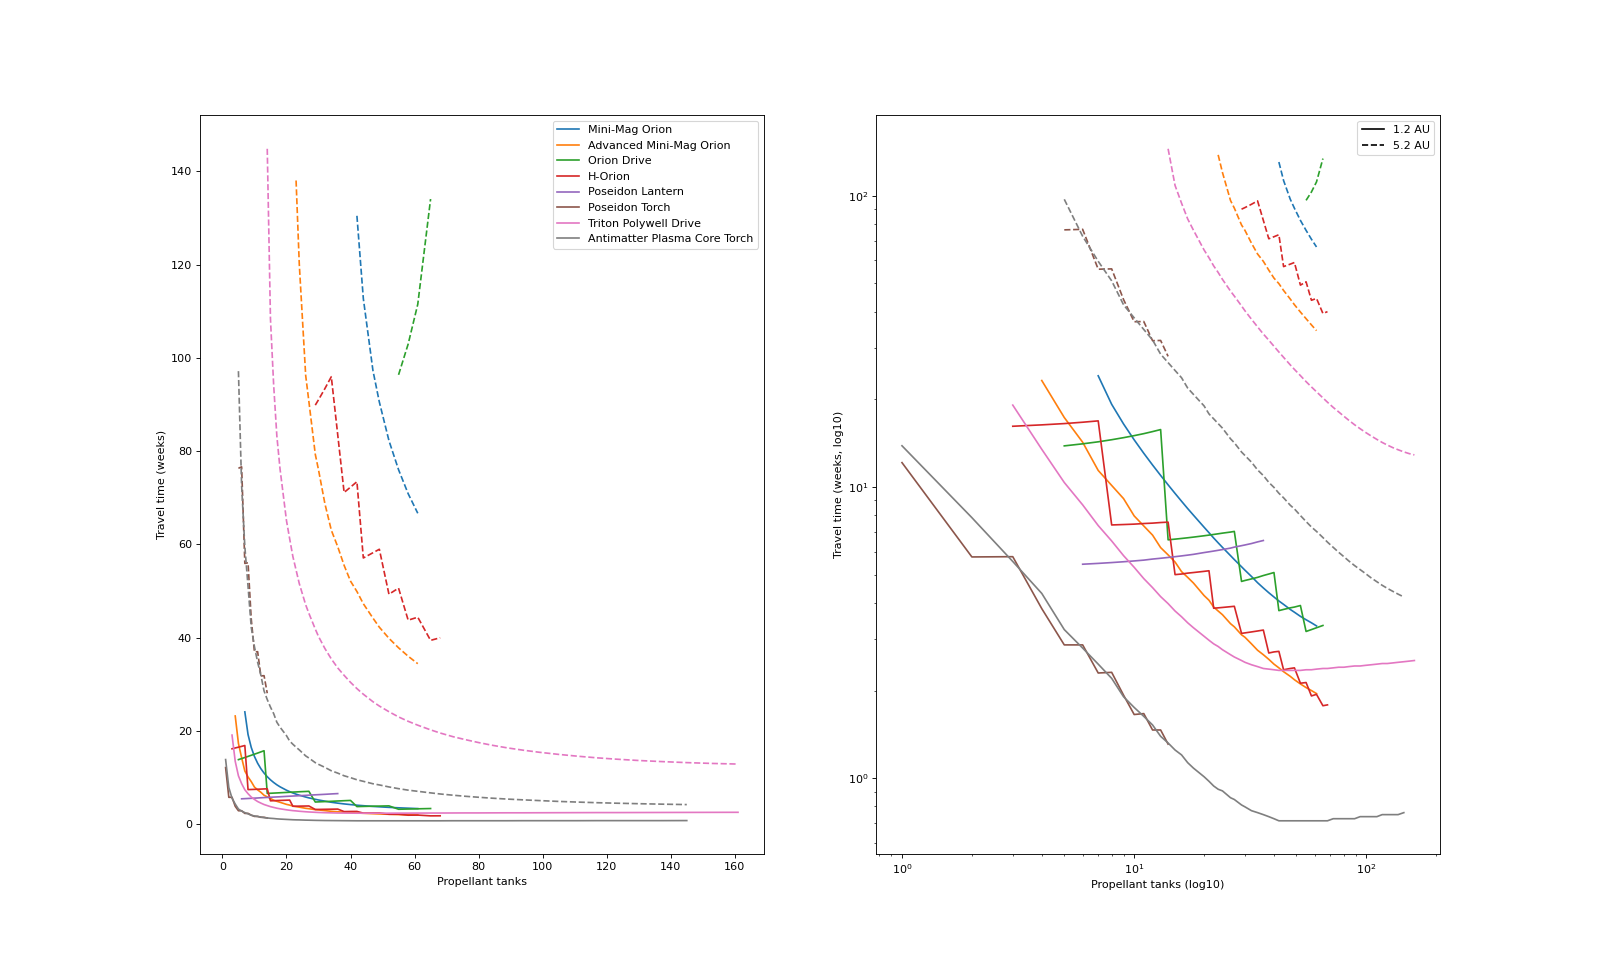

In [24]:
from matplotlib.lines import Line2D

figure(figsize=(20, 12), dpi=80)

au = 1.496e8 * 1e3
ks  = [56,57,58,59,51,52,70,90]
col = ['C0','C1','C2','C3','C4','C5','C6','C7']
js  = [0,1]
lines = ['-','--']

ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

for j in js:
    kk=0
    r1 = 1.*au
    r2 = (4*j+1.2)*au

    for k in ks:
        ve = drives.loc[k,'EV']*1e3
        m_dry = drives.loc[k,'dry_mass']*1e3
        T = drives.loc[k,'thrust']

        prop_cap = drives.loc[k,'tank_cap']
        rb = drives.loc[k,'RP_bins'] - 1
        pms = np.unique((10**np.linspace(0,np.log10(200),num=100)).astype(int))
        pms = pms[pms<prop_cap]
        tts = np.zeros(len(pms))

        for i in range(len(tts)):
            mp0 = pms[i]*1e5
            tts[i] = transfer_time(r1,r2,ve,m_dry,T,mp0)

        if j==0:
            ax1.plot(pms[tts>0], tts[tts>0],
                     label=drives.loc[k,'name'],
                     ls=lines[j], c=col[kk])
            ax2.loglog(pms[tts>0], tts[tts>0],
                       label=drives.loc[k,'name'],
                       ls=lines[j], c=col[kk])
        else:
            ax1.plot(pms[tts>0], tts[tts>0],
                     ls=lines[j], c=col[kk])
            ax2.loglog(pms[tts>0], tts[tts>0],
                       ls=lines[j], c=col[kk])
        kk+=1

leg1 = ax1.legend(loc='upper right')

handles2 = [
    Line2D([0],[0], color='k', ls='-',  label='1.2 AU'),
    Line2D([0],[0], color='k', ls='--', label='5.2 AU'),
]
ax2.legend(handles=handles2, loc='upper right')

ax1.set_xlabel('Propellant tanks')
ax1.set_ylabel('Travel time (weeks)')

ax2.set_xlabel('Propellant tanks (log10)')
ax2.set_ylabel('Travel time (weeks, log10)')



In the script `get_times.py` we are going to apply that function to all the drives, and calculate the transfer times for different orbits across the range of propellant tanks permitted for the given drive.\
The script utilizes `numba` library, so the solver is super-fast (at least 1000 times faster than standard Python loops) and should do all the calculations in under 30 seconds.\
If you want to run it yourself, you probably going to need to install it (`pip install numba`)

# Part 4: Velocity and Range calculations

Here we gonna use stored pre-calculated arrays `t_R.npy` and `p_R.npy`. Those are respectively:
- `t_R.npy` — shape `(n_drives, n_radii)`, expected transfer time (weeks) for each drive and radius, averaged over tested propellant tanks.
- `p_R.npy` — shape `(n_drives, n_radii)`, the representative propellant tank count that produced the averaged time.

These values are calculated inside `get_times.py` script as follows:\
$$\bar t = \frac{\int t(p)\,dp}{p_{max} - p_{min}}.$$
$$\bar p = p(\bar t)$$

Text(0.5, 0, 'Orbit radius (AU)')

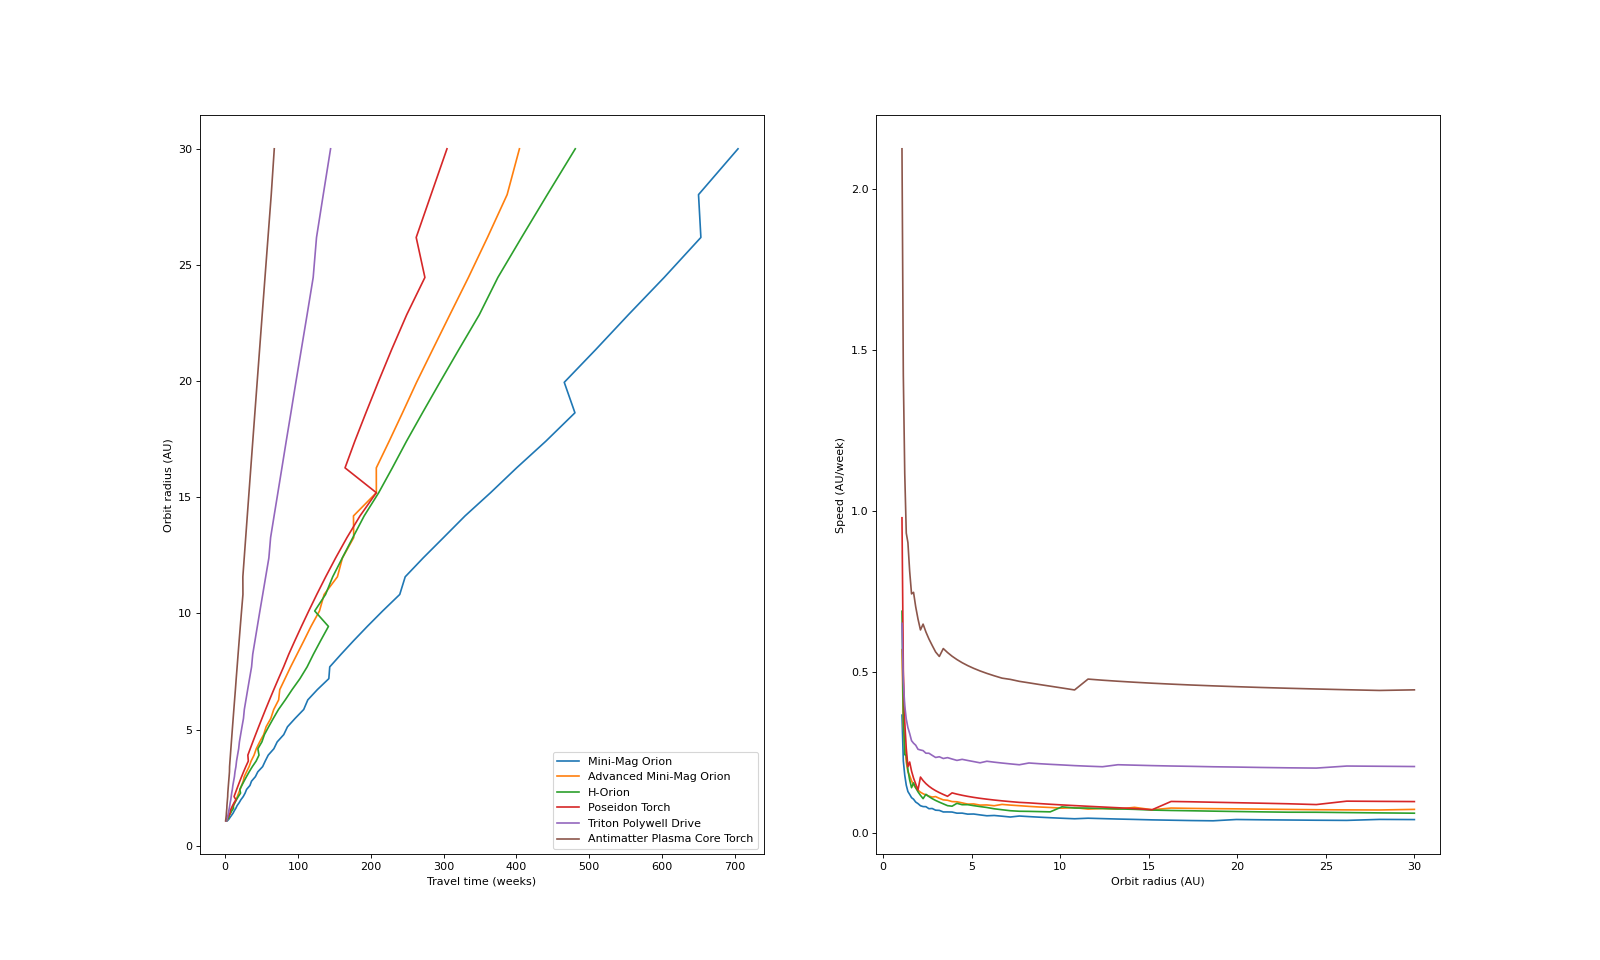

In [25]:
figure(figsize=(20, 12), dpi=80)
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)


ks  = [56,57,59,52,70,90]
t_R = np.load('t_R.npy')

R = 10**np.linspace(0,np.log10(30),num=t_R.shape[1]+1)[1:]


for k in ks:
    t_row = t_R[k]
    ax1.plot(t_row, R, label=drives.loc[k,'name'])
    ax2.plot(R, R/t_row, label=drives.loc[k,'name'])

ax1.legend(loc='lower right')
ax1.set_xlabel('Travel time (weeks)')
ax1.set_ylabel('Orbit radius (AU)')
ax2.set_ylabel('Speed (AU/week)')
ax2.set_xlabel('Orbit radius (AU)')

And here we plot:
1. the orbital radius in AU vs time in weeks (**left**), which takes for the given drive to reach that radius from 1AU. 
2. which leads us to "speed" (AU per week) (**right**), if we divide one by another. This is essentially an average speed that usually is reached during the transfer to the given orbital radius, while using the "average" number of propellant tanks

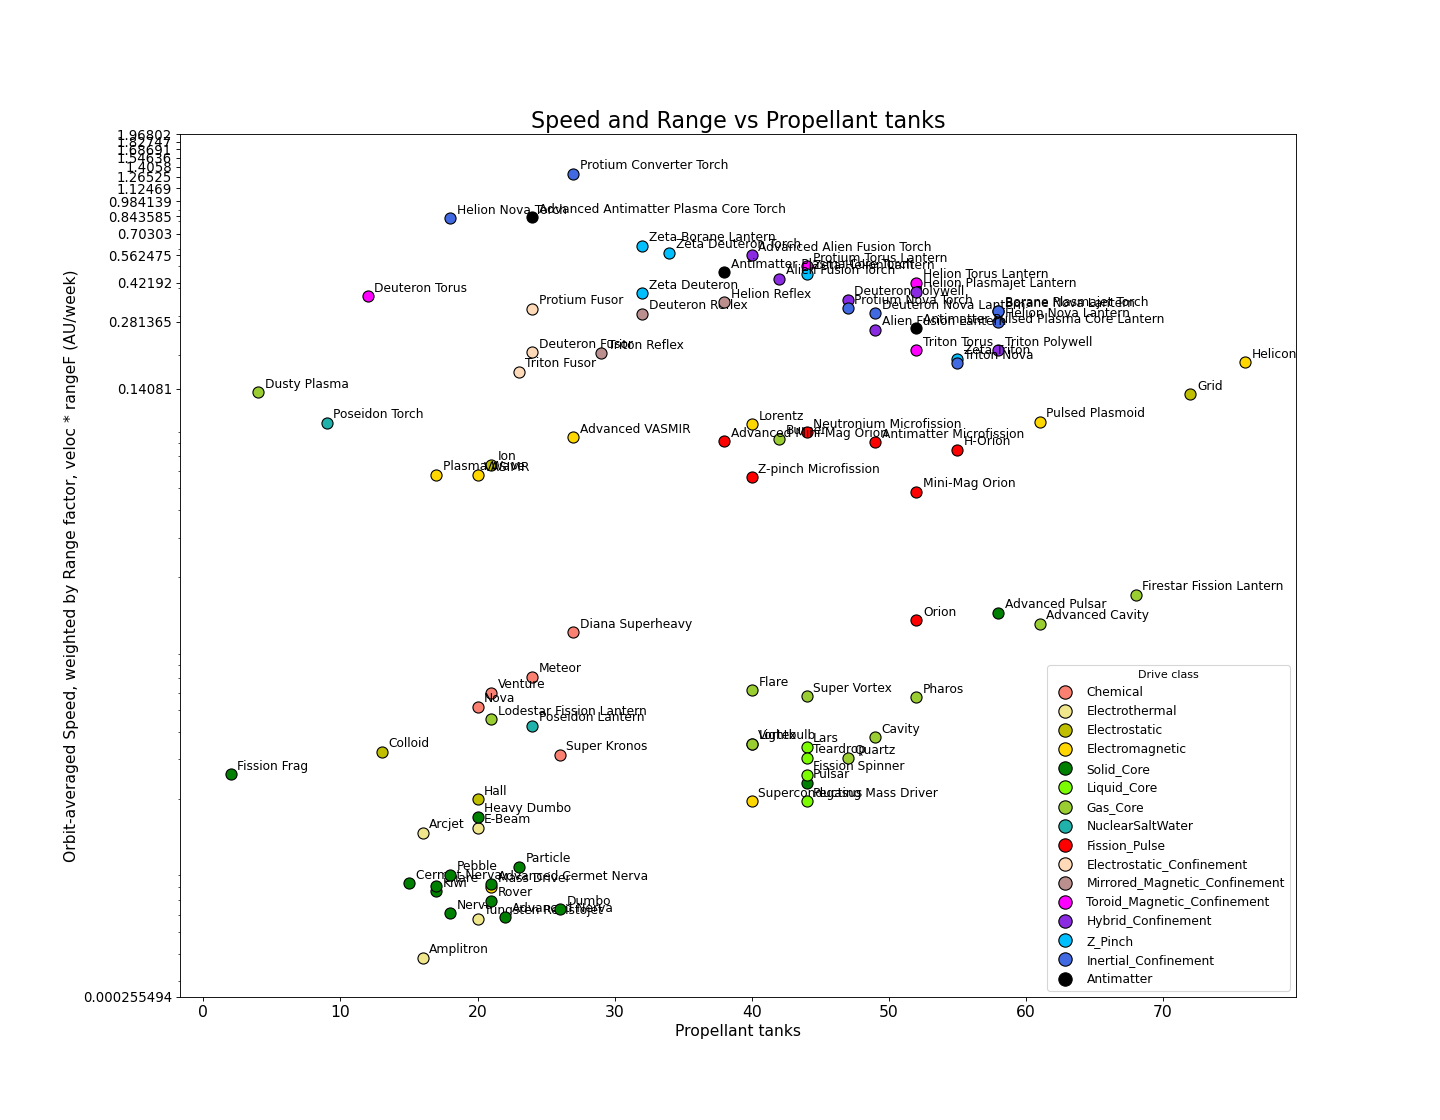

In [42]:
def shortened_name(n):
    full_name = str(n).split()
    if full_name[-1] == 'Drive':
        full_name = full_name[0:-1]
    if full_name[-1] == 'Rocket':
        full_name = full_name[0:-1]
    if full_name[-1] == 'Liquid':
        full_name = full_name[0:-1]
    return ' '.join(full_name)

fig, ax = plt.subplots(figsize=(18, 14), dpi=80)


ks = drives.index

t_R = np.load('t_R.npy')
p_R = np.load('p_R.npy')

veloc = np.zeros(len(ks))
cost_v = np.zeros(len(ks))
rangeF = np.zeros(len(ks))

for k in ks:

    t_row = t_R[k]
    p_row = p_R[k]

    mask = t_R[k]>0
    if sum(mask)==0:
        continue
    t_good = t_row[mask]
    p_good = p_row[mask]
    R_good = R[mask]
    v_good = R_good/t_good

    veloc[k] = np.trapz(v_good, R_good)/(max(R_good)-min(R_good)) # velocity averaged by orbit radius
    rangeF[k] = (max(R_good)-1)/max(R) # range factor (from 0 to 1)
    cost_v[k] = p_good[np.argsort(np.abs(v_good-veloc[k]))][0] # the number of tanks, required for given averaged velocity

    # color by drive class
    cls = drives.loc[k,'class'] if pd.notna(drives.loc[k,'class']) else 'Unknown'
    #if cls in ["Electrostatic_Confinement", "Mirrored_Magnetic_Confinement", "Toroid_Magnetic_Confinement", "Hybrid_Confinement", "Z_Pinch", "Inertial_Confinement", "Antimatter"]:
    #    continue
    color = color_map.get(cls, 'k')

    # shortened label
    short = shortened_name(drives.loc[k,'name'])

    ax.scatter(cost_v[k], veloc[k]*rangeF[k], c=[color], s=100, edgecolors='k', zorder=3)
    ax.annotate(short, xy=(cost_v[k], veloc[k]*rangeF[k]),
                xytext=(6,4), textcoords='offset points', fontsize=11)
    # ax.scatter(cost_v[k], rangeF[k], c=[color], s=70, edgecolors='k', zorder=3)
    # ax.annotate(short, xy=(cost_v[k], rangeF[k]),
    #             xytext=(6,4), textcoords='offset points', fontsize=11)

# legend for classes
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], marker='o', color='w', label=c,
                  markerfacecolor=color_map[c], markersize=12, markeredgecolor='k') for c in classes]
ax.legend(handles=handles, loc='best', title='Drive class', fontsize=11)

# ax.set_xlim(0,1000)
# ax.set_xscale('log')
ax.set_yscale('log')
#ax.set_ylim(0, 0.25)
ax.set_xlabel('Propellant tanks', fontsize=14)
ax.set_ylabel('Orbit-averaged Speed, weighted by Range factor, veloc * rangeF (AU/week)', fontsize=14)
ax.set_title('Speed and Range vs Propellant tanks', fontsize = 20)

ax = plt.gca()
numticks = 15
ax.yaxis.set_major_locator(mticker.LinearLocator(numticks))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g'))
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=12)

And here we calculate the first few major metrics. We calculate per-radius velocity as $v(R) = R / t(R)$ (AU/week). And then:

1. We do the same trick with integrating over all the orbital radii, then dividing by difference between min and max radius available for that particular drive. That gives us **Orbit-averaged Speed for a given drive**: $$\bar v = \frac{\int v(R)\,dR}{R_{max} - R_{min}}.$$ 
2. We also calculate the **Range Factor** for each drive, as maximum R for the given drive - 1, divided by total max R. $RF = (R_{max} - 1)/30$. Here 1 is subtracted, since 1 AU is just Earth orbit, and we're checking if drive can go beyond that. This coefficient is basically a measure of distance for a given drive. 0 means it can't go beoyond Earth orbit, 1 means it can go everywhere.
3. And finally we calculate the **Number of Propellant Tanks**, needed for that speed (as before). Since we already accounted for the **rarity of the propellant materials** (see **Part 2**), the plain number of tanks here simply refects average fuel effectiveness beyond that

On the graph (**1** x **2**) is plotted vs **3**

# Part 5: Pre-combat Intercept chances vs Price calculations

This is where we calculate the chances of intercepting of alien fleets, and that's where we gonna make use of those alien ships stats that we parsed from a savegame earlier.

Text(0.5, 0, 'DV in kps')

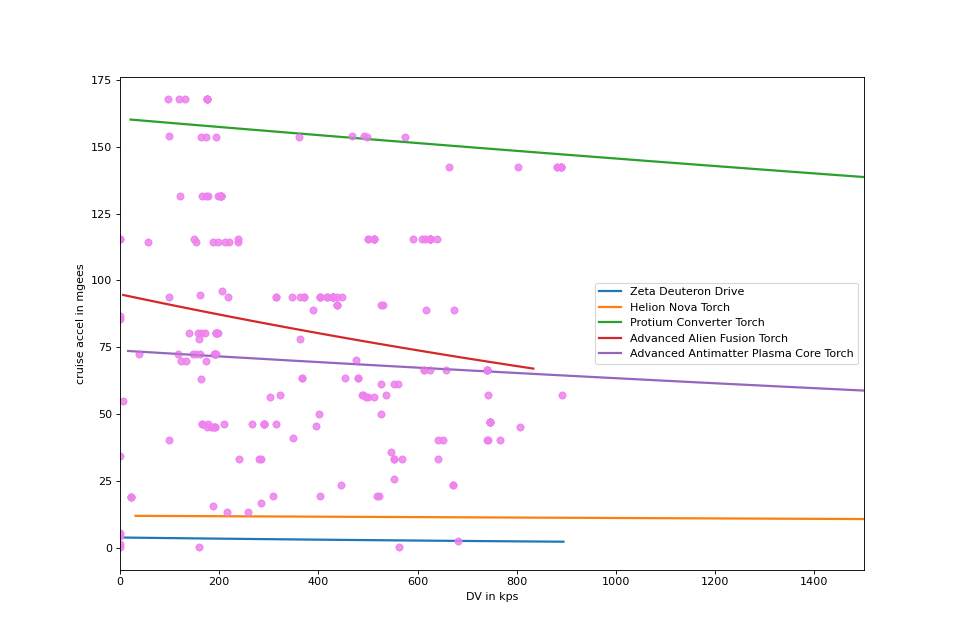

In [27]:
aliens['dv_share'] = aliens['dv_current']/aliens['dv_max']
non_stat = aliens.loc[aliens['dv_share']<0.95]

figure(figsize=(12, 8), dpi=80)

ks  = [75,82,85,88,91]
for k in ks:

    ve = drives.loc[k,'EV']*1e3

    prop_cap = drives.loc[k,'tank_cap']
    rb = drives.loc[k,'RP_bins'] - 1
    props = np.unique((10**np.linspace(0,np.log10(200),num=100)).astype(int))
    props = props[props<prop_cap]
    prop_mass = props*100

    m0 = drives.loc[k,'dry_mass'] + prop_mass
    mf = drives.loc[k,'dry_mass']
    ve = drives.loc[k,'EV']

    cru_a = drives.loc[k,'thrust'] / (m0) / 9.8
    DV = ve * np.log(m0 / mf)
    # print(drives.loc[k,'name'], DV[-1], cru_a[-1])

    plt.plot(DV, cru_a, label = drives.loc[k,'name'],lw=2)
    plt.plot( non_stat['dv_current'],non_stat['cruise_accel']*1000/9.8, 'o', c='violet', alpha=0.3)


plt.legend(loc='best')
plt.xlim(0,1500)
plt.ylabel('cruise accel in mgees')
plt.xlabel('DV in kps')

On a graph above we simply display an example DV and cruise accel in milli-g's for 5 example drives (see the legend) and for alien ships (pink dots). As you can see, alien ships are fairly evenly distributed by accel, but never exceed 1000 DV.

Below is a modified function of how the game calculates the outcome of the pursuit. Well, almost -- it actually calculates the DV required for the chase, and then checks if you have enough. And it also calculates the initial separation as x200 the max weapon range of a given fleet -- so it can reach up to **240000 kilometers**, if you're facing an Alien capital. I put it to 200k km, as a tradeoff.

My modification makes the chase non-symmetrical (the original function is), and also spits the result in a matrix form to account for all the pairs.

Courtesy of user **@fiora** from the official Discord.

In [28]:
def get_pursuit_matrix(a_hum, dv_hum, a_ayy, dv_ayy, D=2e8):
    aH = a_hum[:, None]
    dvH = dv_hum[:, None]
    aA = a_ayy[None, :]
    dvA = dv_ayy[None, :]

    hum_faster = aH > aA
    ayy_faster = aH < aA

    a_min = np.minimum(aH, aA)
    a_max = np.maximum(aH, aA)

    dv_need = a_min * np.sqrt(2.0 * D / (a_max - a_min))
  
    cond1 = hum_faster & (dvH > dv_need) # humans faster -> check hum dv
    cond2 = ayy_faster & (dvA < dv_need) # ayy faster -> check ayy dv

    return cond1 | cond2

1. Compute arrays of human and alien accelerations and DVs (expanded to 2D via broadcasting).
2. Compute acceleration min/max and an approximate DV required for pursuit: $DV_{need} = a_{min} \sqrt{\frac{2 D}{a_{max} - a_{min}}}$

3. If humans have greater accel than aliens, check whether human $DV >= DV_{need}$. If aliens have greater accel, check whether alien $DV < DV_{need}$ (i.e., alien can't escape). Return boolean matrix. 

Orion Drive 28040.861713218925 1.1969676022763929
H-Orion 53154.731455936955 1.2630515325025262
Poseidon Lantern 14674.119811378203 4.286089852557678
Poseidon Torch 72756.43741238235 2.3341500364710943
Triton Polywell Drive 240585.95899951 0.0371528397648407
Antimatter Plasma Core Torch 646050.4667157291 0.4294412588591446


Text(0, 0.5, '% of Ayy ships we catch')

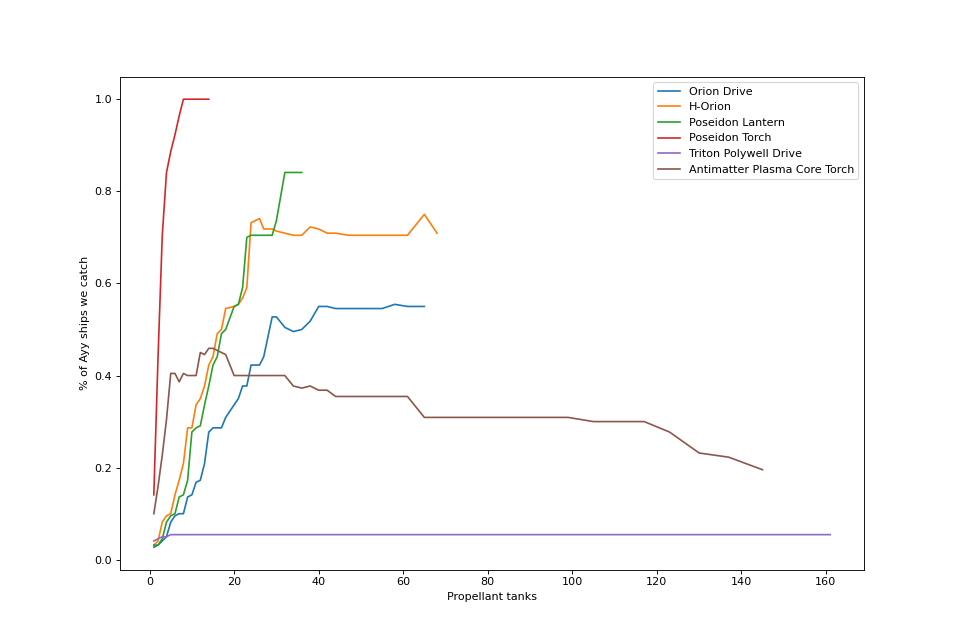

In [29]:
figure(figsize=(12, 8), dpi=80)

ks  = [58,59,51,52,70,90]
for k in ks:

    ve = drives.loc[k,'EV']*1e3

    prop_cap = drives.loc[k,'tank_cap']
    rb = drives.loc[k,'RP_bins'] - 1
    props = np.unique((10**np.linspace(0,np.log10(200),num=100)).astype(int))
    props = props[props<prop_cap]
    prop_mass = props*100

    m0 = drives.loc[k,'dry_mass'] + prop_mass
    mf = drives.loc[k,'dry_mass']
    ve = drives.loc[k,'EV']

    cru_a = drives.loc[k,'thrust'] / (m0) / 1000
    DV = ve * np.log(m0 / mf) * 1000
    print(drives.loc[k,'name'], DV[-1], cru_a[-1])

    pursue = get_pursuit_matrix(cru_a, DV, non_stat['cruise_accel'].values, non_stat['dv_current'].values*1000)

    plt.plot(props, np.mean(pursue, axis=1), label = drives.loc[k,'name'])
    # plt.plot(cru_a, DV, label = drives.loc[k,'name'])
    # plt.plot(non_stat['cruise_accel'], non_stat['dv_current']*1000, 'o')


plt.legend(loc='best')
 
plt.xlabel('Propellant tanks')
plt.ylabel('% of Ayy ships we catch')


Here we test the results of how our function works: we calculate the **Mean % share of alien ships that we can catch**, based on our given values of DV and cruise accel, that we get from the given propellant tanks.\
And then we plot that against **Propellant tanks** (same idea as in the case with velocities)

(as before, the cap for propellant tanks is limited by the resource rarity and the game stage)

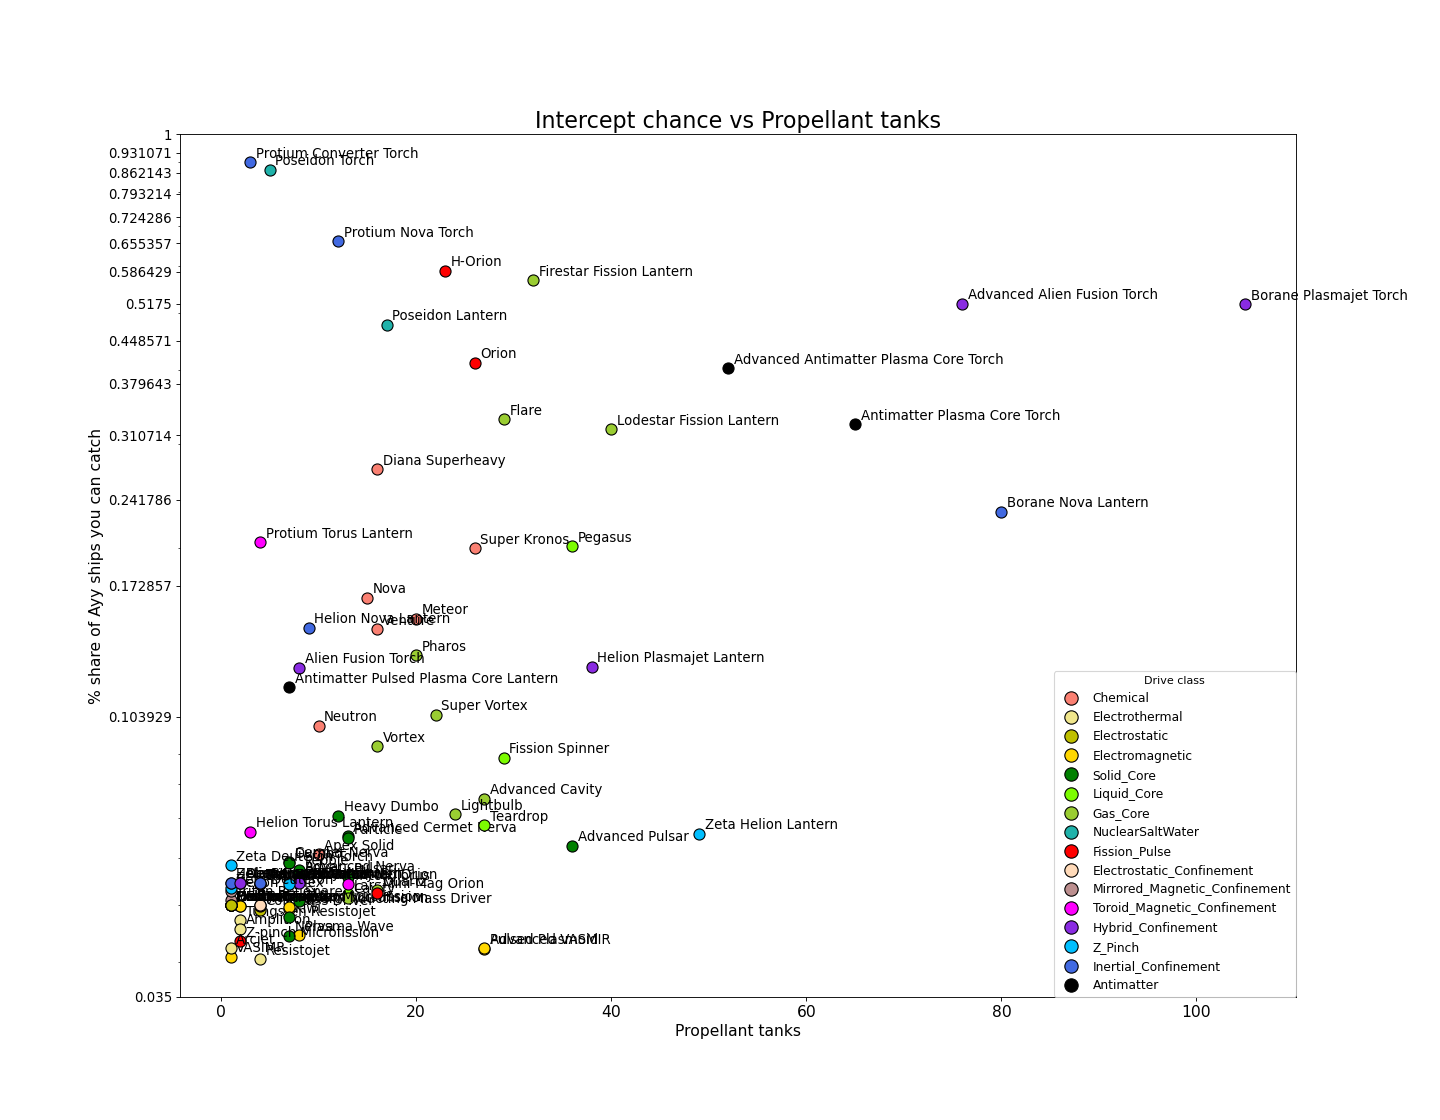

In [30]:
ks = drives.index

pursue = np.zeros(len(drives))
cost_p = np.zeros(len(drives))

fig, ax = plt.subplots(figsize=(18, 14), dpi=80)

for k in ks:

    ve = drives.loc[k,'EV']*1e3
    
    prop_cap = drives.loc[k,'tank_cap']
    rb = drives.loc[k,'RP_bins'] - 1
    props = np.unique((10**np.linspace(0,np.log10(200),num=100)).astype(int))
    props = props[props<prop_cap]
    prop_mass = props*100
    if len(props)<1:
        continue

    m0 = drives.loc[k,'dry_mass'] + prop_mass
    mf = drives.loc[k,'dry_mass']
    ve = drives.loc[k,'EV']

    cru_a = drives.loc[k,'thrust'] / (m0) / 1000
    DV = ve * np.log(m0 / mf) * 1000
    # print(drives.loc[k,'name'], DV[-1], cru_a[-1])

    pursue_matrix = get_pursuit_matrix(cru_a, DV, non_stat['cruise_accel'].values, non_stat['dv_current'].values*1000)
    mean_pur = np.mean(pursue_matrix, axis=1)
    pursue[k] = np.trapz(mean_pur, props)/(max(props)-min(props)) # expected value for pursue prob (integral of mean_p divided by props range)
    cost_p[k] = props[np.argsort(np.abs(mean_pur-pursue[k]))][0] # the number of tanks, required for expected pursue prob

    # color by drive class
    cls = drives.loc[k,'class'] if pd.notna(drives.loc[k,'class']) else 'Unknown'
    color = color_map.get(cls, 'k')

    # shortened label
    short = shortened_name(drives.loc[k,'name'])

    ax.scatter(cost_p[k],
               pursue[k], c=[color], s=100, edgecolors='k', zorder=3)
    ax.annotate(short, xy=(cost_p[k],
                           pursue[k]),
                xytext=(5,4), textcoords='offset points', fontsize=12)

# legend for classes
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], marker='o', color='w', label=c,
                  markerfacecolor=color_map[c], markersize=12, markeredgecolor='k') for c in classes]
ax.legend(
    handles=handles,
    title='Drive class',
    loc='best',
    # loc='upper left',
    # bbox_to_anchor=(1.005, 1.0),
    borderaxespad=0,
    fontsize=11
)

ax.set_ylim(0.035,1.)
# ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Propellant tanks', fontsize=14)
ax.set_ylabel('% share of Ayy ships you can catch', fontsize=14)
ax.set_title('Intercept chance vs Propellant tanks', fontsize = 20)

ax = plt.gca()
numticks = 15
ax.yaxis.set_major_locator(mticker.LinearLocator(numticks))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g'))
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=12)


And here is our second major chunk of metrics.

Here we do the same trick with integrating, as before:
1.  we calculate the **intercept chance, averaged by all the tanks, available for the given drive**
2. as well as we calculate the **Number of Propellant tanks**, which give you this particular chance

And we do that for all the drives, and then plot that.

# Part 6: Final Rating

In [31]:
drives['veloc'] = veloc
drives['pursue'] = pursue
drives['range'] = rangeF 
drives['prop_share'] = drives['tank_cap']/(cost_v +cost_p )

Those are our key metrics:
1. `drives['veloc']` - orbit and propellant tank averaged Speed in AU/week
2. `drives['pursue']` - propellant averaged Intercept chance
3. `drives['range']` - Range factor
4. `drives['prop_share']` - this is an indicator of propellant effectiveness, basically what share of the max allowed tank you spend on average transfer + intercept -- low scores here means you basically have to refill very often 

In [32]:
def log_norm(a):
    a = a.copy()
    mask = (a>1e-8)&((a<np.inf))
    b = a[mask]
    # print(b[:10])
    b = np.log10(b) - min(np.log10(b))
    b = b/max(b)*100
    a[mask] = b
    a[~mask] = 0

    return np.round(a,1)

With this function we'll create a normalized logarithmic rating for each category. I.e. velocities will be ranked from 0 to 100, then intercept chances, and inverse costs

Log is needed, IMO, because the game's progress scales more or less exponentially in most regards.

In [33]:
drives['rating'] = log_norm(drives['veloc'] * drives['pursue'] * drives['prop_share'] * drives['range'])

### Y-axis: Total Rating:
So, after that we can simply multiply our individual metric ranges together:
- Averaged intercept chances
- Averaged speed across available orbits
- Inverted sum of propellant tanks which we spend for both intercept and for transfer (you're spending them for the same ship, after all).

And then multiply by maximum range rating squared (which represents the area that the drive can cover). Essentially it's a huge penalty for weak drives that can not go beyond Earth -- without that term Chem Rockets would be one of the best drives -- and even then they are far from the worst.

In [34]:
drives['RP_rating'] = log_norm(drives['RP_focus']-100)

### X-axis: Focused Research Points Rating
Now, remember during the parsing phase we created some weird metrics called "Focused Research Points"? That's basically the same Research Points that you normally spend on Projects and Tech, only this one you spend to unlock THIS SPECIFIC DRIVE/PLANT. It doesn't account (or at least it tries to) for other stuff you unlock along the way. E.g. Arc Lasers for ICF Drives.

#### note: unlike the other ratings, this one is inversed. Lower means better. 0 means you don't have to research anything to unlock it. 100 means you need to spend crazy amount of RP

In [35]:
drives[['name','veloc','pursue','prop_share','rating']].sort_values(by='rating').head(50)
# drives

,name,veloc,pursue,prop_share,rating
0,Apex Solid Rocket,NaN,0.060963,0.726770,0.0
2,Neutron Liquid Rocket,NaN,0.100401,0.787335,0.0
9,Amplitron Drive,0.078995,0.045629,1.579478,0.0
93,Resistojet,NaN,0.040472,1.052985,0.0
92,Pion Torch,0.000000,0.000000,inf,0.0
22,Nerva Drive,0.080676,0.044406,1.137224,0.9
26,Advanced Nerva Drive,0.077671,0.056119,0.947687,1.0
27,Dumbo,0.083973,0.058916,0.861534,1.2
7,Tungsten Resistojet,0.076008,0.047115,1.292300,1.9
24,Rover Drive,0.091581,0.055857,0.980366,2.6


## ULTIMATE plotting: Rating vs Research Points

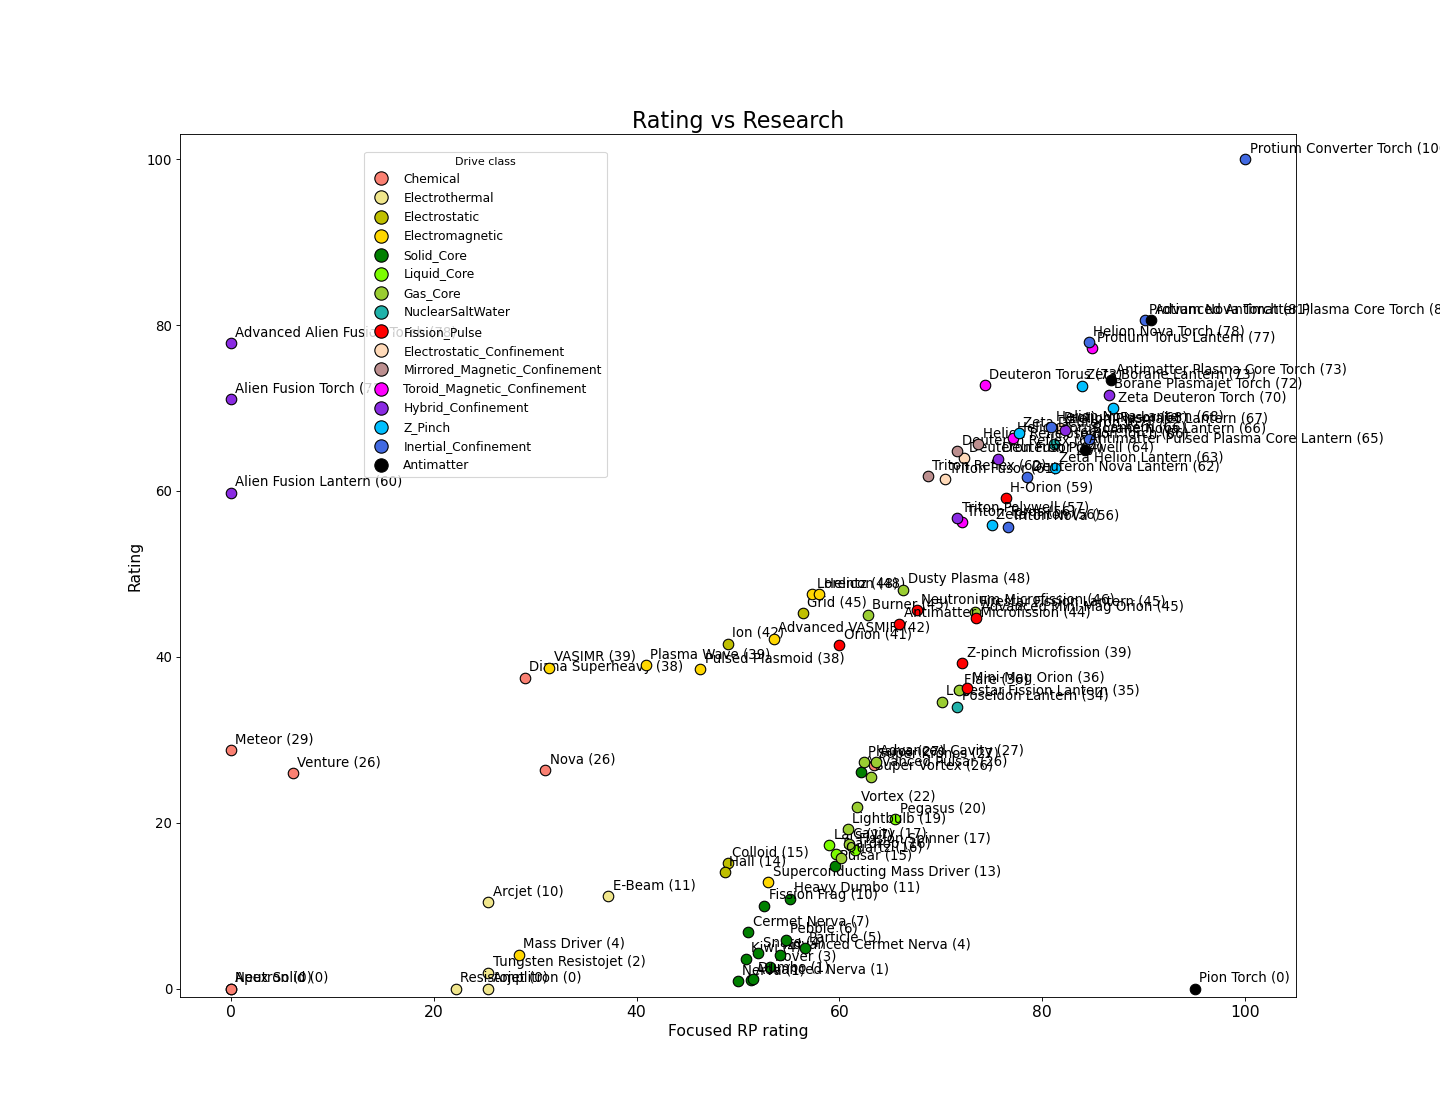

In [36]:
ks = drives.index

fig, ax = plt.subplots(figsize=(18, 14), dpi=80)

for k in ks:

    # color by drive class
    cls = drives.loc[k,'class'] if pd.notna(drives.loc[k,'class']) else 'Unknown'
    color = color_map.get(cls, 'k')

    # shortened label
    short = shortened_name(drives.loc[k,'name']) + ' (' + str(round(drives.loc[k,'rating'])) + ')'

    ax.scatter(drives.loc[k,'RP_rating'],
               drives.loc[k,'rating'], c=[color], s=90, edgecolors='k', zorder=3)
    ax.annotate(short, xy=(drives.loc[k,'RP_rating'],
                           drives.loc[k,'rating']),
                xytext=(4,6), textcoords='offset points', fontsize=12)

# legend for classes
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], marker='o', color='w', label=c,
                  markerfacecolor=color_map[c], markersize=12, markeredgecolor='k') for c in classes]


ax.legend(
    handles=handles,
    title='Drive class',
    loc='upper left',
    bbox_to_anchor=(0.165, 0.98),
    borderaxespad=0,
    fontsize=11
)

ax.set_ylim(-1,103)
# ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Focused RP rating', fontsize=14)
ax.set_ylabel('Rating', fontsize=14)
ax.set_title('Rating vs Research', fontsize = 20)

ax = plt.gca()
# # numticks = 15
# # ax.yaxis.set_major_locator(mticker.LinearLocator(numticks))
# # ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g'))
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=12)


In [37]:
def plot_stage_table(rp_bins, stage):
    import matplotlib.colors as mcolors
    cmap = plt.cm.RdYlGn  # red=low, green=high

    # scaled metrics
    vel_raw = drives['veloc'] * drives['range']
    vel_scaled = log_norm(vel_raw.fillna(0).values)
    pursue_scaled = log_norm(drives['pursue'].fillna(0).values)
    inv_scaled = log_norm(drives['prop_share'].fillna(0).values)

    drives['_vel_scaled'] = vel_scaled
    drives['_pursue_scaled'] = pursue_scaled
    drives['_inv_scaled'] = inv_scaled

    left, right = rp_bins[0], rp_bins[1]
    mask = (drives['RP_raw'] >= left) & (drives['RP_raw'] <= right)
    df = drives.loc[mask, ['name','class','_vel_scaled','_pursue_scaled','_inv_scaled','rating', 'RP_rating']].copy()
    df = df.sort_values(by='rating', ascending=False).reset_index(drop=True)

    cols = ["Name","RP_rating","Velocity","Pursue","Fuel Effectiveness","Rating"]
    cell_text = []
    cell_colors = []

    for _, row in df.iterrows():
        name = row['name']
        cls = row['class'] if pd.notna(row['class']) else 'Unknown'
        rp  = row['RP_rating']
        vel = row['_vel_scaled']
        pur = row['_pursue_scaled']
        inv = row['_inv_scaled']
        rating = row['rating'] if not pd.isna(row['rating']) else 0.0

        cell_text.append([name, f"{rp:.1f}", f"{vel:.1f}", f"{pur:.1f}", f"{inv:.1f}", f"{rating:.1f}"])

        # colors
        name_color = color_map.get(cls, 'lightgrey')
        # RP_rating numeric color: inverted (100 -> red, 0 -> green)
        cmap_r = plt.cm.RdYlGn_r
        def num_color(v, cmap_local=cmap):
            c = cmap_local(float(v)/100.0)
            return mcolors.to_rgba(c)
        def num_color_inv(v):
            c = cmap_r(float(v)/100.0)
            return mcolors.to_rgba(c)

        row_colors = [
            name_color,
            num_color_inv(rp),
            num_color(vel),
            num_color(pur),
            num_color(inv),
            num_color(rating if rating<=100 else 100)
        ]
        cell_colors.append(row_colors)

    # draw table
    nrows = len(cell_text)
    fig_h = max(2, 0.25 * nrows)
    fig, ax = plt.subplots(figsize=(12, fig_h), dpi=100)
    ax.axis('off')
    tbl = ax.table(cellText=cell_text, colLabels=cols, cellColours=cell_colors,
                   cellLoc='left', colLoc='center', loc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(12)
    tbl.scale(1, 1.1)
    plt.tight_layout()
    # if a cell background is black ('k'), make the text white so it's readable
    for i in range(nrows):
        for j in range(len(cols)):
            bg = cell_colors[i][j]
            if isinstance(bg, str) and bg == 'k':
                cell = tbl[(i+1, j)]  # data rows start at 1 (0 is header)
                cell.get_text().set_color('white')
    plt.title(stage, fontweight='bold', fontsize = 25)
    return fig, ax

(<Figure size 1200x1100 with 1 Axes>, <Axes: title={'center': 'Early Game'}>)

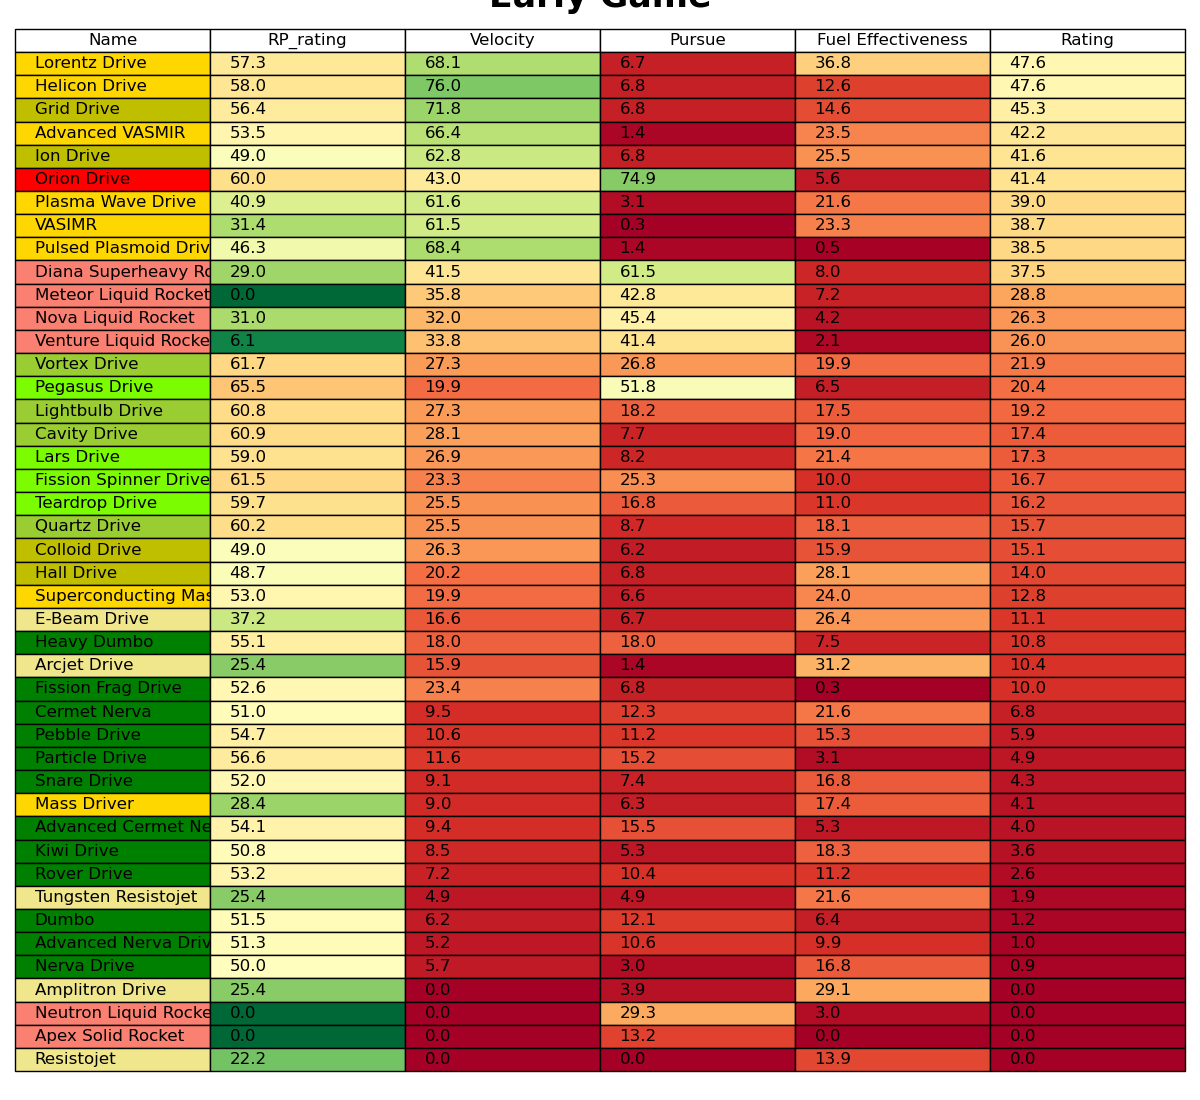

In [38]:
plot_stage_table([0,50000], 'Early Game')

(<Figure size 1200x825 with 1 Axes>, <Axes: title={'center': 'Mid Game'}>)

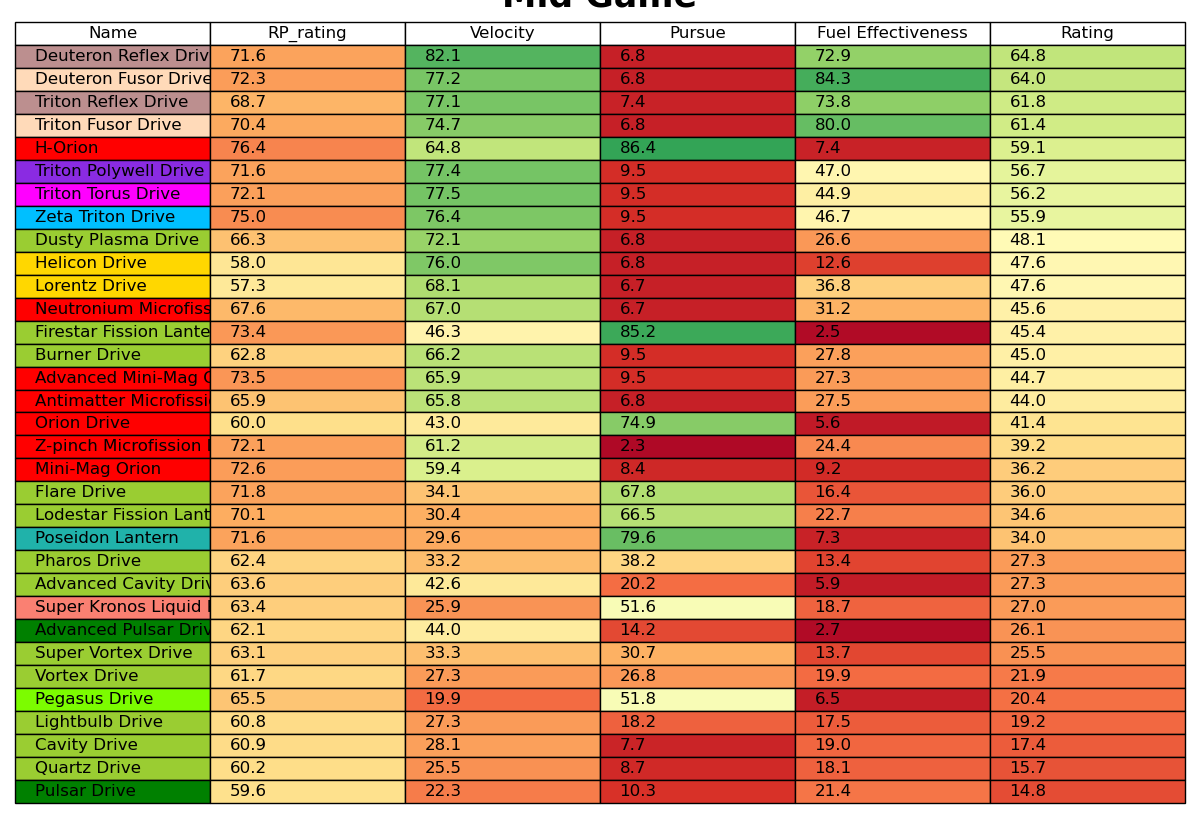

In [39]:
plot_stage_table([30000,400000], 'Mid Game')

(<Figure size 1200x775 with 1 Axes>, <Axes: title={'center': 'Late Game'}>)

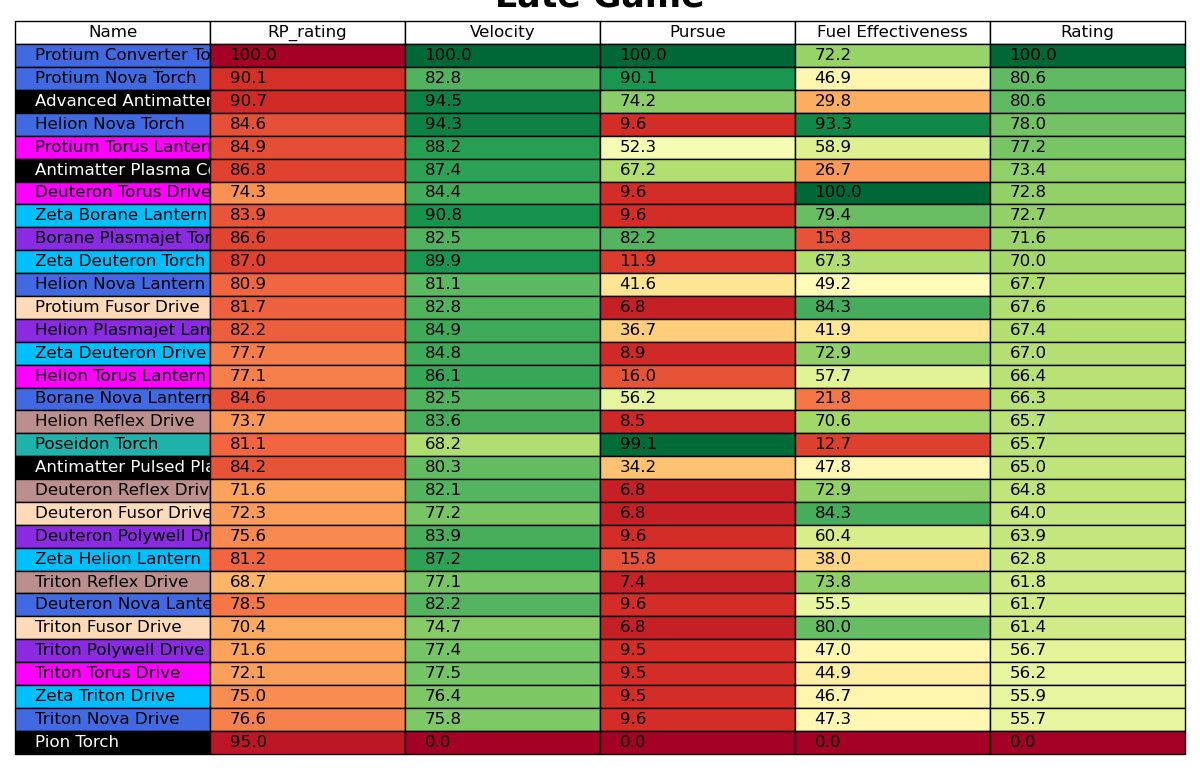

In [41]:
plot_stage_table([295000,10000000], 'Late Game')